# Explainable Dual-Attention BiLSTM Encoder–Decoder for Natural Gas Consumption Forecasting

This notebook implements and evaluates the proposed BiLSTM dual-attention encoder–decoder architecture for short-term natural gas consumption forecasting using Algerian hourly data. Sections cover: data preprocessing, feature engineering, hyperparameter search, baseline model comparison, final model training, and SHAP-based interpretability analysis.

In [ ]:
import random
import numpy as np
import tensorflow as tf

# ── Reproducibility seeds (ensures consistent results across runs) ─────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# ───────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, MultiHeadAttention, LayerNormalization, Concatenate, Add, Bidirectional, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf


In [ ]:
def prepare_enhanced_data(df, input_steps=24, output_steps=12, target_col='Normalized Consumption'):

    # 1. Sort and set datetime index
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')

    # 3. Include all features
    feature_cols = [
        target_col, 'temperature', 'Hour', 'DayOfWeek',
        'DayOfMonth', 'Month', 'holidaybinary',
        'HourSin', 'DayOfWeekSin', 'DayOfMonthSin', 'MonthSin', 'HolidaySin',
        'Wet_Bulb_Temperature_2_Meters', 'Wind_Speed_at_10_Meters',
        'temperture_2_metre', 'Relative_Humidity_at_2_Meters',
    ]

    # Remove NaN rows
    df = df.dropna()

    # ------------------------------
    # 4. Separate target and features (unscaled)
    # ------------------------------
    target_data = df[[target_col]].values
    feature_data = df[feature_cols].drop(columns=[target_col]).values

    # ------------------------------
    # 5. Create raw sequences (UNSCALED)
    # ------------------------------
    X_raw, y_raw = [], []
    for i in range(len(df) - input_steps - output_steps + 1):
        seq_x = df[feature_cols].iloc[i:i+input_steps].values
        seq_y = df[target_col].iloc[i+input_steps:i+input_steps+output_steps].values
        X_raw.append(seq_x)
        y_raw.append(seq_y)

    X_raw = np.array(X_raw)
    y_raw = np.array(y_raw)

    # ------------------------------
    # 6. Split BEFORE SCALING (correct)
    # ------------------------------
    X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
        X_raw, y_raw, test_size=0.3, shuffle=False
    )

    X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
        X_temp_raw, y_temp_raw, test_size=0.5, shuffle=False
    )

    # ------------------------------
    # 7. Fit scalers ONLY on TRAINING DATA (correct)
    # ------------------------------
    feature_scaler = StandardScaler()
    target_scaler = MinMaxScaler()

    # Fit only on training
    feature_scaler.fit(X_train_raw[:, :, 1:].reshape(-1, len(feature_cols)-1))
    target_scaler.fit(y_train_raw.reshape(-1, 1))

    # ------------------------------
    # 8. Apply scaling to X and y
    # ------------------------------
    def scale_X(X):
        X_scaled = np.zeros_like(X)
        # scale target
        X_scaled[:, :, 0] = target_scaler.transform(X[:, :, 0].reshape(-1, 1)).reshape(X.shape[0], X.shape[1])
        # scale features
        X_scaled[:, :, 1:] = feature_scaler.transform(
            X[:, :, 1:].reshape(-1, len(feature_cols)-1)
        ).reshape(X.shape[0], X.shape[1], len(feature_cols)-1)
        return X_scaled

    def scale_y(y):
        return target_scaler.transform(y.reshape(-1,1)).reshape(y.shape)

    X_train = scale_X(X_train_raw)
    X_val   = scale_X(X_val_raw)
    X_test  = scale_X(X_test_raw)

    y_train = scale_y(y_train_raw)
    y_val   = scale_y(y_val_raw)
    y_test  = scale_y(y_test_raw)

    # ------------------------------
    # 9. Prepare decoder inputs (same as your code)
    # ------------------------------
    def create_decoder_input(X_batch, y_batch):
        decoder_input = np.zeros((len(X_batch), output_steps, len(feature_cols)))
        for i in range(len(X_batch)):
            decoder_input[i, 0, :] = X_batch[i, -1, :]
            for j in range(1, output_steps):
                decoder_input[i, j, :] = decoder_input[i, j-1, :]
                decoder_input[i, j, 0] = y_batch[i, j-1]  # Teacher forcing
        return decoder_input

    decoder_input_train = create_decoder_input(X_train, y_train)
    decoder_input_val   = create_decoder_input(X_val, y_val)
    decoder_input_test  = create_decoder_input(X_test, y_test)

    # ------------------------------
    return (
        X_train, decoder_input_train, y_train,
        X_val,   decoder_input_val,   y_val,
        X_test,  decoder_input_test,  y_test,
        {'feature_scaler': feature_scaler, 'target_scaler': target_scaler},
        feature_cols
    )


In [ ]:
import pandas as pd

# Load dataset: Algerian hourly natural gas consumption with meteorological features
df = pd.read_csv('new_data_temp.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (8760, 21)


,Unnamed: 0,Date,Normalized Consumption,temperature,Hour,DayOfWeek,DayOfMonth,Month,Year,holidaybinary,...,DayOfWeekSin,DayOfMonthSin,MonthSin,HolidaySin,Consumption_Lag1,Consumption_Lag2,Wet_Bulb_Temperature_2_Meters,Wind_Speed_at_10_Meters,temperture_2_metre,Relative_Humidity_at_2_Meters
0,0,2014-01-01 00:00:00,0.589314,5.640536,0,2,1,1,2014,1,...,0.974928,0.201299,0.5,0.017213,NaN,NaN,2.30,3.41,5.22,65.94
1,1,2014-01-01 01:00:00,0.616253,5.247807,1,2,1,1,2014,1,...,0.974928,0.201299,0.5,0.017213,0.589314,NaN,1.83,3.56,4.54,67.81
2,2,2014-01-01 02:00:00,0.617690,4.900791,2,2,1,1,2014,1,...,0.974928,0.201299,0.5,0.017213,0.616253,0.589314,1.40,3.71,3.80,70.81
3,3,2014-01-01 03:00:00,0.607589,4.589947,3,2,1,1,2014,1,...,0.974928,0.201299,0.5,0.017213,0.617690,0.616253,1.20,3.82,3.44,72.38
4,4,2014-01-01 04:00:00,0.604764,4.308440,4,2,1,1,2014,1,...,0.974928,0.201299,0.5,0.017213,0.607589,0.617690,1.03,3.92,3.23,72.81


## 1. Data Preparation & Feature Engineering


📊 Data Shapes:
  X_train: (6106, 24, 16)
  dec_train: (6106, 12, 16)
  y_train: (6106, 12)
  X_val: (1308, 24, 16)
  y_val: (1308, 12)

🔍 Running hyperparameter search...

STARTING FOCUSED HYPERPARAMETER SEARCH
Testing 7 configurations


[Configuration 1/7]

Testing: baseline
Config: {'name': 'baseline', 'lstm_units': 128, 'num_heads': 2, 'key_dim': 16, 'dropout_rate': 0.2, 'dense_units': 32}
Epoch 1/80


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['encoder_input', 'decoder_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 65s 415ms/step - loss: 0.5625 - mae: 0.1660 - val_loss: 0.1390 - val_mae: 0.1027 - learning_rate: 0.0010
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 312ms/step - loss: 0.0931 - mae: 0.0879 - val_loss: 0.0227 - val_mae: 0.0805 - learning_rate: 0.0010
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 277ms/step - loss: 0.0170 - mae: 0.0775 - val_loss: 0.0083 - val_mae: 0.0738 - learning_rate: 0.0010
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 275ms/step - loss: 0.0074 - mae: 0.0715 - val_loss: 0.0062 - val_mae: 0.0715 - learning_rate: 0.0010
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 269ms/step - loss: 0.0053 - mae: 0.0659 - val_loss: 0.0047 - val_mae: 0.0657 - learning_rate: 0.0010
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 270ms/step - loss: 0.0043 - mae: 0.0619 - val_loss: 0.0039 - val_mae: 0.0592 - learning_rate: 0.0010
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 297ms/step - loss: 0.0037 - mae: 0.0593 - val_loss: 0.0038 - val_mae: 0.0625 - learning_rate: 0.0010
Epoch 8/80

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['encoder_input', 'decoder_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - loss: 0.3456 - mae: 0.1811 - val_loss: 0.1357 - val_mae: 0.1256 - learning_rate: 0.0010
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - loss: 0.1009 - mae: 0.0978 - val_loss: 0.0441 - val_mae: 0.1218 - learning_rate: 0.0010
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0301 - mae: 0.0854 - val_loss: 0.0163 - val_mae: 0.0986 - learning_rate: 0.0010
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0115 - mae: 0.0777 - val_loss: 0.0102 - val_mae: 0.0983 - learning_rate: 0.0010
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0068 - mae: 0.0731 - val_loss: 0.0054 - val_mae: 0.0684 - learning_rate: 0.0010
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0052 - mae: 0.0683 - val_loss: 0.0043 - val_mae: 0.0639 - learning_rate: 0.0010
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0044 - mae: 0.0648 - val_loss: 0.0034 - val_mae: 0.0559 - learning_rate: 0.0010
Epoch 8/80
48/48

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['encoder_input', 'decoder_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 39s 498ms/step - loss: 0.9652 - mae: 0.1918 - val_loss: 0.1328 - val_mae: 0.0907 - learning_rate: 0.0010
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 397ms/step - loss: 0.0831 - mae: 0.0886 - val_loss: 0.0197 - val_mae: 0.0664 - learning_rate: 0.0010
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 461ms/step - loss: 0.0169 - mae: 0.0765 - val_loss: 0.0087 - val_mae: 0.0591 - learning_rate: 0.0010
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 28s 573ms/step - loss: 0.0087 - mae: 0.0690 - val_loss: 0.0056 - val_mae: 0.0549 - learning_rate: 0.0010
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 562ms/step - loss: 0.0060 - mae: 0.0633 - val_loss: 0.0042 - val_mae: 0.0511 - learning_rate: 0.0010
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 559ms/step - loss: 0.0048 - mae: 0.0605 - val_loss: 0.0038 - val_mae: 0.0525 - learning_rate: 0.0010
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 466ms/step - loss: 0.0041 - mae: 0.0581 - val_loss: 0.0031 - val_mae: 0.0495 - learning_rate: 0.0010
Epoch 8/80

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['encoder_input', 'decoder_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - loss: 0.5709 - mae: 0.1677 - val_loss: 0.1485 - val_mae: 0.1020 - learning_rate: 0.0010
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - loss: 0.0996 - mae: 0.0828 - val_loss: 0.0266 - val_mae: 0.0834 - learning_rate: 0.0010
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - loss: 0.0192 - mae: 0.0736 - val_loss: 0.0092 - val_mae: 0.0694 - learning_rate: 0.0010
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - loss: 0.0079 - mae: 0.0676 - val_loss: 0.0059 - val_mae: 0.0645 - learning_rate: 0.0010
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - loss: 0.0052 - mae: 0.0614 - val_loss: 0.0042 - val_mae: 0.0566 - learning_rate: 0.0010
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - loss: 0.0040 - mae: 0.0573 - val_loss: 0.0038 - val_mae: 0.0592 - learning_rate: 0.0010
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - loss: 0.0034 - mae: 0.0551 - val_loss: 0.0033 - val_mae: 0.0552 - learning_rate: 0.0010
Epoch 8/80
48/48

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['encoder_input', 'decoder_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - loss: 0.5690 - mae: 0.1933 - val_loss: 0.1372 - val_mae: 0.0957 - learning_rate: 0.0010
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - loss: 0.0943 - mae: 0.1005 - val_loss: 0.0225 - val_mae: 0.0865 - learning_rate: 0.0010
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - loss: 0.0177 - mae: 0.0847 - val_loss: 0.0076 - val_mae: 0.0709 - learning_rate: 0.0010
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - loss: 0.0081 - mae: 0.0776 - val_loss: 0.0050 - val_mae: 0.0633 - learning_rate: 0.0010
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - loss: 0.0058 - mae: 0.0716 - val_loss: 0.0038 - val_mae: 0.0568 - learning_rate: 0.0010
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - loss: 0.0048 - mae: 0.0672 - val_loss: 0.0039 - val_mae: 0.0634 - learning_rate: 0.0010
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - loss: 0.0043 - mae: 0.0647 - val_loss: 0.0030 - val_mae: 0.0518 - learning_rate: 0.0010
Epoch 8/80
48/48

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['encoder_input', 'decoder_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 211ms/step - loss: 0.5585 - mae: 0.1699 - val_loss: 0.1314 - val_mae: 0.0978 - learning_rate: 0.0010
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - loss: 0.0876 - mae: 0.0920 - val_loss: 0.0195 - val_mae: 0.0767 - learning_rate: 0.0010
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - loss: 0.0149 - mae: 0.0777 - val_loss: 0.0061 - val_mae: 0.0623 - learning_rate: 0.0010
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - loss: 0.0062 - mae: 0.0686 - val_loss: 0.0040 - val_mae: 0.0550 - learning_rate: 0.0010
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - loss: 0.0046 - mae: 0.0639 - val_loss: 0.0031 - val_mae: 0.0495 - learning_rate: 0.0010
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 197ms/step - loss: 0.0038 - mae: 0.0603 - val_loss: 0.0027 - val_mae: 0.0496 - learning_rate: 0.0010
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - loss: 0.0034 - mae: 0.0578 - val_loss: 0.0026 - val_mae: 0.0496 - learning_rate: 0.0010
Epoch 8/80
48/48

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['encoder_input', 'decoder_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - loss: 0.5665 - mae: 0.1721 - val_loss: 0.1388 - val_mae: 0.0883 - learning_rate: 0.0010
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - loss: 0.0942 - mae: 0.0883 - val_loss: 0.0224 - val_mae: 0.0765 - learning_rate: 0.0010
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 232ms/step - loss: 0.0168 - mae: 0.0731 - val_loss: 0.0075 - val_mae: 0.0653 - learning_rate: 0.0010
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - loss: 0.0069 - mae: 0.0662 - val_loss: 0.0049 - val_mae: 0.0602 - learning_rate: 0.0010
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step - loss: 0.0050 - mae: 0.0622 - val_loss: 0.0040 - val_mae: 0.0537 - learning_rate: 0.0010
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - loss: 0.0040 - mae: 0.0588 - val_loss: 0.0031 - val_mae: 0.0499 - learning_rate: 0.0010
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 233ms/step - loss: 0.0034 - mae: 0.0559 - val_loss: 0.0025 - val_mae: 0.0447 - learning_rate: 0.0010
Epoch 8/80

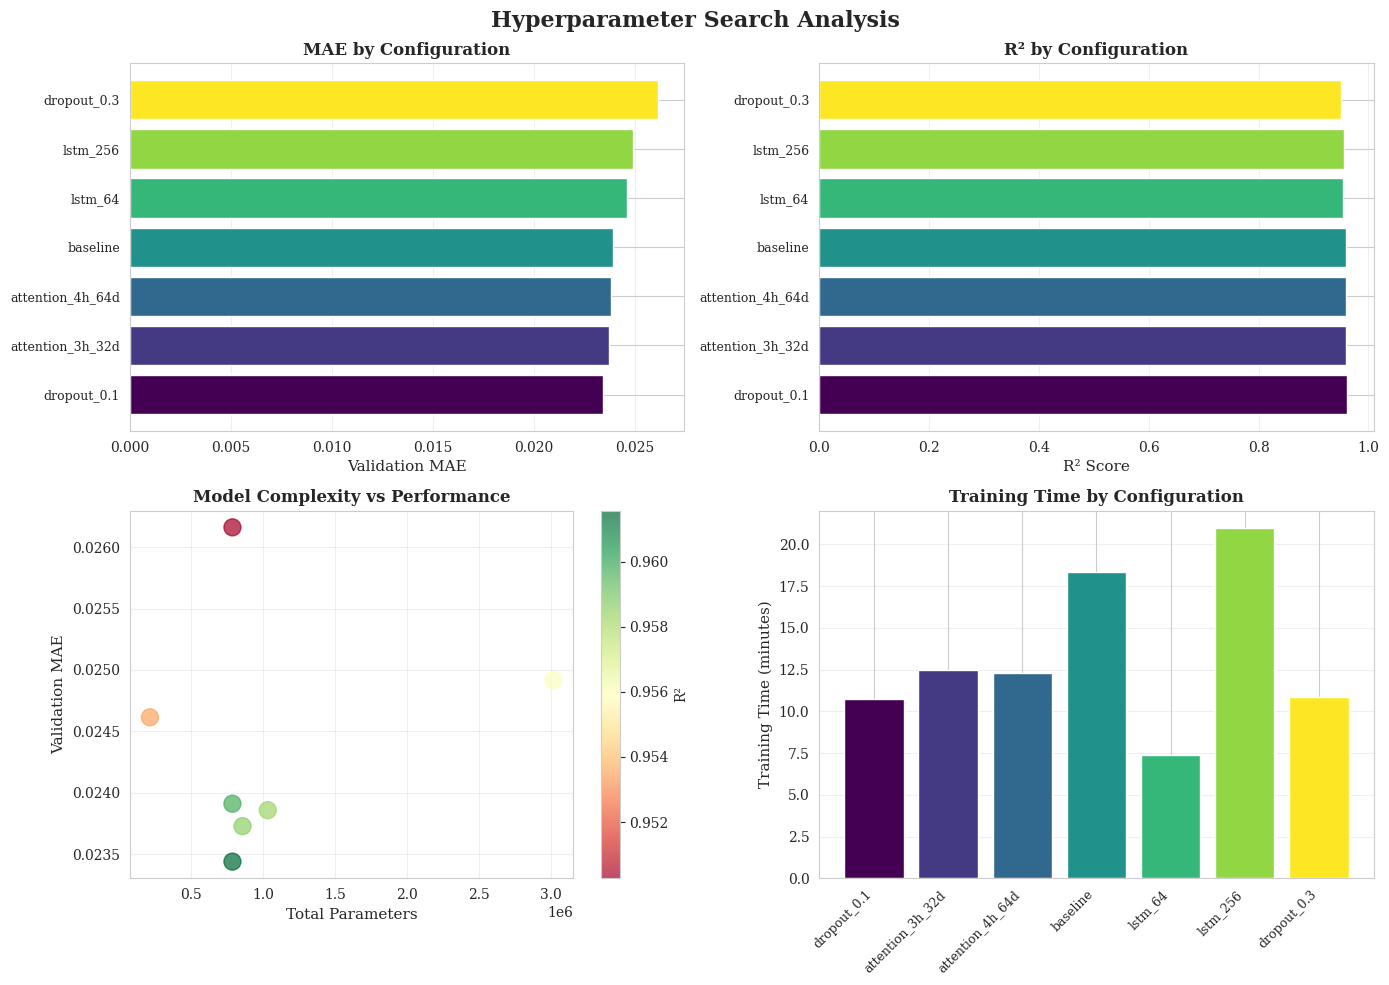


✨ Using best configuration for final training:
  LSTM units: 128
  Dropout: 0.1
  Attention: 2 heads, key_dim=16

🎯 Training final model...
Epoch 1/80


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['encoder_input', 'decoder_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 202ms/step - loss: 0.5588 - mae: 0.1559 - val_loss: 0.1356 - val_mae: 0.0930 - learning_rate: 0.0010
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - loss: 0.0901 - mae: 0.0811 - val_loss: 0.0212 - val_mae: 0.0792 - learning_rate: 0.0010
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 182ms/step - loss: 0.0151 - mae: 0.0699 - val_loss: 0.0065 - val_mae: 0.0615 - learning_rate: 0.0010
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - loss: 0.0058 - mae: 0.0628 - val_loss: 0.0044 - val_mae: 0.0575 - learning_rate: 0.0010
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - loss: 0.0040 - mae: 0.0583 - val_loss: 0.0037 - val_mae: 0.0568 - learning_rate: 0.0010
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - loss: 0.0034 - mae: 0.0562 - val_loss: 0.0031 - val_mae: 0.0526 - learning_rate: 0.0010
Epoch 7/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 182ms/step - loss: 0.0028 - mae: 0.0527 - val_loss: 0.0030 - val_mae: 0.0525 - learning_rate: 0.0010
Epoch 8/80
48/48

In [ ]:
"""
Complete integration code for hyperparameter search in your notebook.
Replace your existing train_and_evaluate function with this code.
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dense, Dropout, Add,
    MultiHeadAttention, LayerNormalization, TimeDistributed, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import json


# ============================================================================
# 1. MODIFIED MODEL CREATION FUNCTION (with hyperparameters)
# ============================================================================

def create_enhanced_model(input_shape, output_steps, num_features,
                          lstm_units=128, dense_units=32, dropout_rate=0.2,
                          num_heads=2, key_dim=16, l2_reg=0.001,
                          learning_rate=0.001):
    """
    Enhanced seq2seq model with configurable hyperparameters.

    Args:
        input_shape: (timesteps, features)
        output_steps: prediction horizon
        num_features: number of input features
        lstm_units: LSTM hidden units (default: 128)
        dense_units: Dense layer units (default: 32)
        dropout_rate: dropout probability (default: 0.2)
        num_heads: attention heads (default: 2)
        key_dim: attention key dimension (default: 16)
        l2_reg: L2 regularization coefficient (default: 0.001)
        learning_rate: optimizer learning rate (default: 0.001)
    """
    # Encoder
    encoder_input = Input(shape=input_shape, name="encoder_input")

    x = Bidirectional(
        LSTM(lstm_units, return_sequences=True, kernel_regularizer=l2(l2_reg))
    )(encoder_input)
    x = Dropout(dropout_rate)(x)

    x_res = Bidirectional(
        LSTM(lstm_units, return_sequences=True, kernel_regularizer=l2(l2_reg))
    )(x)
    x = Add()([x, x_res])
    x = Dropout(dropout_rate)(x)

    attn_out = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_out = LayerNormalization()(attn_out)

    encoder_out = Concatenate()([x, attn_out])

    last_step = encoder_out[:, -1, :]
    state_h = Dense(lstm_units)(last_step)
    state_c = Dense(lstm_units)(last_step)
    encoder_states = [state_h, state_c]

    # Decoder
    decoder_input = Input(shape=(output_steps, num_features), name="decoder_input")

    feat_attn = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(
        decoder_input, decoder_input
    )
    feat_attn = LayerNormalization()(feat_attn)

    decoder_lstm = LSTM(lstm_units, return_sequences=True, name="decoder_lstm")
    decoder_out = decoder_lstm(feat_attn, initial_state=encoder_states)
    decoder_out = Dropout(dropout_rate)(decoder_out)

    x = TimeDistributed(Dense(dense_units, activation="swish"))(decoder_out)
    x = Dropout(dropout_rate)(x)

    output = TimeDistributed(Dense(1), name="output")(x)

    model = Model([encoder_input, decoder_input], output, name="seq2seq_model")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


# ============================================================================
# 2. HYPERPARAMETER SEARCH CLASS
# ============================================================================

class HyperparameterSearch:
    """Hyperparameter search for your model."""

    def __init__(self, X_train, dec_train, y_train,
                 X_val, dec_val, y_val, scalers):
        self.X_train = X_train
        self.dec_train = dec_train
        self.y_train = y_train
        self.X_val = X_val
        self.dec_val = dec_val
        self.y_val = y_val
        self.scalers = scalers
        self.results = []

    def evaluate_metrics(self, y_true, y_pred):
        """Calculate MAE and R² with inverse scaling."""
        y_true_flat = y_true.reshape(-1)
        y_pred_flat = y_pred.reshape(-1)

        if 'target_scaler' in self.scalers:
            y_true_unscaled = self.scalers['target_scaler'].inverse_transform(
                y_true.reshape(-1, 1)
            ).flatten()
            y_pred_unscaled = self.scalers['target_scaler'].inverse_transform(
                y_pred.reshape(-1, 1)
            ).flatten()
        else:
            y_true_unscaled = y_true_flat
            y_pred_unscaled = y_pred_flat

        mae = mean_absolute_error(y_true_unscaled, y_pred_unscaled)
        r2 = r2_score(y_true_unscaled, y_pred_unscaled)

        return mae, r2

    def test_configuration(self, config, epochs=80, batch_size=128):
        """Test a single hyperparameter configuration."""
        config_name = config.get('name', 'unnamed')
        print(f"\n{'='*70}")
        print(f"Testing: {config_name}")
        print(f"Config: {config}")
        print(f"{'='*70}")

        # Create model
        model = create_enhanced_model(
            input_shape=(self.X_train.shape[1], self.X_train.shape[2]),
            output_steps=self.y_train.shape[1],
            num_features=self.X_train.shape[2],
            lstm_units=config.get('lstm_units', 128),
            dense_units=config.get('dense_units', 32),
            dropout_rate=config.get('dropout_rate', 0.2),
            num_heads=config.get('num_heads', 2),
            key_dim=config.get('key_dim', 16),
            l2_reg=config.get('l2_reg', 0.001),
            learning_rate=config.get('learning_rate', 0.001)
        )

        # Callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_mae',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_mae',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=1
            )
        ]

        # Train
        start_time = datetime.now()

        try:
            history = model.fit(
                [self.X_train, self.dec_train],
                self.y_train,
                validation_data=([self.X_val, self.dec_val], self.y_val),
                epochs=epochs,
                batch_size=batch_size,
                callbacks=callbacks,
                verbose=1
            )
        except Exception as e:
            print(f"Training failed: {e}")
            return None

        training_time = (datetime.now() - start_time).total_seconds()

        # Evaluate
        y_val_pred = model.predict([self.X_val, self.dec_val], verbose=0)
        val_mae, val_r2 = self.evaluate_metrics(self.y_val, y_val_pred)

        # Store results
        result = {
            'name': config_name,
            'lstm_units': config.get('lstm_units', 128),
            'dense_units': config.get('dense_units', 32),
            'dropout_rate': config.get('dropout_rate', 0.2),
            'num_heads': config.get('num_heads', 2),
            'key_dim': config.get('key_dim', 16),
            'l2_reg': config.get('l2_reg', 0.001),
            'learning_rate': config.get('learning_rate', 0.001),
            'val_mae': float(val_mae),
            'val_r2': float(val_r2),
            'epochs_trained': len(history.history['loss']),
            'training_time_sec': training_time,
            'total_params': model.count_params()
        }

        self.results.append(result)

        print(f"\n{'─'*70}")
        print(f"Results for {config_name}:")
        print(f"  Validation MAE: {val_mae:.4f}")
        print(f"  Validation R²:  {val_r2:.4f}")
        print(f"  Training time:  {training_time:.1f}s ({training_time/60:.1f} min)")
        print(f"  Parameters:     {model.count_params():,}")
        print(f"{'─'*70}\n")

        # Clear memory
        del model
        tf.keras.backend.clear_session()

        return result

    def focused_search(self, epochs=80, batch_size=128):
        """Run focused hyperparameter search."""
        configs = [
            # Baseline
            {'name': 'baseline', 'lstm_units': 128, 'num_heads': 2,
             'key_dim': 16, 'dropout_rate': 0.2, 'dense_units': 32},

            # Test LSTM capacity
            {'name': 'lstm_64', 'lstm_units': 64, 'num_heads': 2,
             'key_dim': 16, 'dropout_rate': 0.2, 'dense_units': 32},
            {'name': 'lstm_256', 'lstm_units': 256, 'num_heads': 2,
             'key_dim': 16, 'dropout_rate': 0.2, 'dense_units': 32},

            # Test dropout
            {'name': 'dropout_0.1', 'lstm_units': 128, 'num_heads': 2,
             'key_dim': 16, 'dropout_rate': 0.1, 'dense_units': 32},
            {'name': 'dropout_0.3', 'lstm_units': 128, 'num_heads': 2,
             'key_dim': 16, 'dropout_rate': 0.3, 'dense_units': 32},

            # Test attention
            {'name': 'attention_3h_32d', 'lstm_units': 128, 'num_heads': 3,
             'key_dim': 32, 'dropout_rate': 0.2, 'dense_units': 32},
            {'name': 'attention_4h_64d', 'lstm_units': 128, 'num_heads': 4,
             'key_dim': 64, 'dropout_rate': 0.2, 'dense_units': 32},
        ]

        print(f"\n{'='*70}")
        print(f"STARTING FOCUSED HYPERPARAMETER SEARCH")
        print(f"Testing {len(configs)} configurations")
        print(f"{'='*70}\n")

        for i, config in enumerate(configs, 1):
            print(f"\n[Configuration {i}/{len(configs)}]")
            try:
                self.test_configuration(config, epochs=epochs, batch_size=batch_size)
            except Exception as e:
                print(f"Configuration {config['name']} failed: {e}")
                continue

        return self.get_results_dataframe()

    def get_results_dataframe(self):
        """Return results as DataFrame."""
        if not self.results:
            return pd.DataFrame()
        df = pd.DataFrame(self.results)
        df = df.sort_values('val_mae')
        return df

    def save_results(self, filename='hyperparameter_results'):
        """Save results to CSV and JSON."""
        df = self.get_results_dataframe()
        df.to_csv(f"{filename}.csv", index=False)

        with open(f"{filename}.json", 'w') as f:
            json.dump(self.results, f, indent=2)

        print(f"\n✅ Results saved to {filename}.csv and {filename}.json")
        return df

    def print_summary(self):
        """Print summary of results."""
        df = self.get_results_dataframe()

        if df.empty:
            print("No results to display!")
            return

        print("\n" + "="*80)
        print("HYPERPARAMETER SEARCH RESULTS SUMMARY")
        print("="*80)

        print(f"\nTotal configurations tested: {len(df)}")
        print(f"Best validation MAE: {df.iloc[0]['val_mae']:.4f}")
        print(f"Best validation R²: {df.iloc[0]['val_r2']:.4f}")

        print("\n" + "-"*80)
        print("TOP 5 CONFIGURATIONS:")
        print("-"*80)

        display_cols = ['name', 'val_mae', 'val_r2', 'lstm_units', 'num_heads',
                        'key_dim', 'dropout_rate', 'total_params']
        print(df.head()[display_cols].to_string(index=False))

        print("\n" + "-"*80)
        print("BEST CONFIGURATION:")
        print("-"*80)
        best = df.iloc[0]
        for key, value in best.items():
            if isinstance(value, float):
                print(f"  {key:20s}: {value:.6f}")
            else:
                print(f"  {key:20s}: {value}")

        return df

    def plot_results(self, save_path='hyperparameter_analysis.png'):
        """Create visualization of results."""
        df = self.get_results_dataframe()

        if df.empty:
            print("No results to plot!")
            return

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Hyperparameter Search Analysis', fontsize=16, fontweight='bold')

        # 1. MAE comparison
        ax = axes[0, 0]
        colors = plt.cm.viridis(np.linspace(0, 1, len(df)))
        bars = ax.barh(range(len(df)), df['val_mae'], color=colors)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['name'], fontsize=9)
        ax.set_xlabel('Validation MAE', fontsize=11)
        ax.set_title('MAE by Configuration', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')

        # 2. R² comparison
        ax = axes[0, 1]
        bars = ax.barh(range(len(df)), df['val_r2'], color=colors)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['name'], fontsize=9)
        ax.set_xlabel('R² Score', fontsize=11)
        ax.set_title('R² by Configuration', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')

        # 3. Parameters vs Performance
        ax = axes[1, 0]
        scatter = ax.scatter(df['total_params'], df['val_mae'],
                           s=150, c=df['val_r2'], cmap='RdYlGn', alpha=0.7)
        ax.set_xlabel('Total Parameters', fontsize=11)
        ax.set_ylabel('Validation MAE', fontsize=11)
        ax.set_title('Model Complexity vs Performance', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='R²')

        # 4. Training time
        ax = axes[1, 1]
        bars = ax.bar(range(len(df)), df['training_time_sec']/60, color=colors)
        ax.set_xticks(range(len(df)))
        ax.set_xticklabels(df['name'], rotation=45, ha='right', fontsize=9)
        ax.set_ylabel('Training Time (minutes)', fontsize=11)
        ax.set_title('Training Time by Configuration', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✅ Plots saved to {save_path}")
        plt.show()


# ============================================================================
# 3. MODIFIED MAIN TRAINING FUNCTION
# ============================================================================

def train_and_evaluate(df, run_hyperparam_search=False):
    """
    Train and evaluate model with optional hyperparameter search.

    Args:
        df: your dataframe
        run_hyperparam_search: if True, run hyperparameter search first
    """
    # Prepare data (your existing function)
    (X_train, dec_train, y_train,
     X_val, dec_val, y_val,
     X_test, dec_test, y_test,
     scalers, feature_cols) = prepare_enhanced_data(df)

    print(f"\n📊 Data Shapes:")
    print(f"  X_train: {X_train.shape}")
    print(f"  dec_train: {dec_train.shape}")
    print(f"  y_train: {y_train.shape}")
    print(f"  X_val: {X_val.shape}")
    print(f"  y_val: {y_val.shape}")

    # ========================================================================
    # OPTION 1: Run hyperparameter search
    # ========================================================================
    if run_hyperparam_search:
        print("\n🔍 Running hyperparameter search...")

        search = HyperparameterSearch(
            X_train, dec_train, y_train,
            X_val, dec_val, y_val,
            scalers
        )

        results = search.focused_search(epochs=80, batch_size=128)
        search.print_summary()
        search.save_results('hyperparameter_results')
        search.plot_results('hyperparameter_analysis.png')

        # Get best configuration
        best_config = results.iloc[0]
        print(f"\n✨ Using best configuration for final training:")
        print(f"  LSTM units: {best_config['lstm_units']}")
        print(f"  Dropout: {best_config['dropout_rate']}")
        print(f"  Attention: {best_config['num_heads']} heads, key_dim={best_config['key_dim']}")

        # Create model with best hyperparameters
        model = create_enhanced_model(
            input_shape=(X_train.shape[1], X_train.shape[2]),
            output_steps=y_train.shape[1],
            num_features=len(feature_cols),
            lstm_units=int(best_config['lstm_units']),
            dropout_rate=best_config['dropout_rate'],
            num_heads=int(best_config['num_heads']),
            key_dim=int(best_config['key_dim']),
            dense_units=int(best_config['dense_units'])
        )

    # ========================================================================
    # OPTION 2: Use default hyperparameters (your original approach)
    # ========================================================================
    else:
        print("\n🚀 Training with default hyperparameters...")
        model = create_enhanced_model(
            input_shape=(X_train.shape[1], X_train.shape[2]),
            output_steps=y_train.shape[1],
            num_features=len(feature_cols)
        )

    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
    ]

    # Train final model
    print("\n🎯 Training final model...")
    history = model.fit(
        [X_train, dec_train], y_train,
        validation_data=([X_val, dec_val], y_val),
        epochs=80,
        batch_size=128,
        callbacks=callbacks,
        verbose=1
    )

    # --- Helper Function to Evaluate Metrics ---
    def evaluate_set(X, dec_input, y_true, prefix):
        y_pred = model.predict([X, dec_input], verbose=0)

        y_true_flat = y_true.reshape(-1)
        y_pred_flat = y_pred.reshape(-1)

        if 'target_scaler' in scalers:
            y_true_unscaled = scalers['target_scaler'].inverse_transform(
                y_true.reshape(-1, 1)
            ).flatten()
            y_pred_unscaled = scalers['target_scaler'].inverse_transform(
                y_pred.reshape(-1, 1)
            ).flatten()
        else:
            y_true_unscaled = y_true_flat
            y_pred_unscaled = y_pred_flat

        mae = mean_absolute_error(y_true_unscaled, y_pred_unscaled)
        r2 = r2_score(y_true_unscaled, y_pred_unscaled)

        print(f"{prefix} MAE: {mae:.4f}")
        print(f"{prefix} R²:  {r2:.4f}")

        return mae, r2

    # --- Evaluate All Sets ---
    print("\n📊 Final Model Evaluation:")
    print("="*50)
    print("\n📊 Training Set:")
    evaluate_set(X_train, dec_train, y_train, "Train")

    print("\n📊 Validation Set:")
    evaluate_set(X_val, dec_val, y_val, "Val")

    print("\n📊 Test Set:")
    test_mae, test_r2 = evaluate_set(X_test, dec_test, y_test, "Test")

    return model, history, scalers




model, history, scalers = train_and_evaluate(df, run_hyperparam_search=True)

## 4. Final Model Training with Optimized Hyperparameters

Trains the proposed BiLSTM dual-attention encoder–decoder using the best configuration from hyperparameter search (`attention_4h_64d`): LSTM units=128, 4 attention heads, key_dim=64, dropout=0.2.

In [ ]:
df=pd.read_csv('new_data_temp.csv')

🎯 Training FINAL MODEL with best hyperparameters:
   LSTM units: 128
   Dropout: 0.2
   Attention: 4h, key_dim=64

🚀 Starting FINAL training...
Epoch 1/80


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['encoder_input', 'decoder_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 188ms/step - loss: 0.4599 - mae: 0.1779 - val_loss: 0.0341 - val_mae: 0.0707 - learning_rate: 0.0010
Epoch 2/80
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - loss: 0.0232 - mae: 0.0848 - val_loss: 0.0077 - val_mae: 0.0611 - learning_rate: 0.0010
Epoch 3/80
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 177ms/step - loss: 0.0076 - mae: 0.0715 - val_loss: 0.0044 - val_mae: 0.0546 - learning_rate: 0.0010
Epoch 4/80
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 175ms/step - loss: 0.0049 - mae: 0.0641 - val_loss: 0.0032 - val_mae: 0.0486 - learning_rate: 0.0010
Epoch 5/80
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - loss: 0.0039 - mae: 0.0605 - val_loss: 0.0025 - val_mae: 0.0458 - learning_rate: 0.0010
Epoch 6/80
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 173ms/step - loss: 0.0032 - mae: 0.0561 - val_loss: 0.0022 - val_mae: 0.0447 - learning_rate: 0.0010
Epoch 7/80
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 172ms/step - loss: 0.0029 - mae: 0.0540 - val_loss: 0.0024 - val_mae: 0.0486 - learning_rate: 0.0010
Epoch 8/80

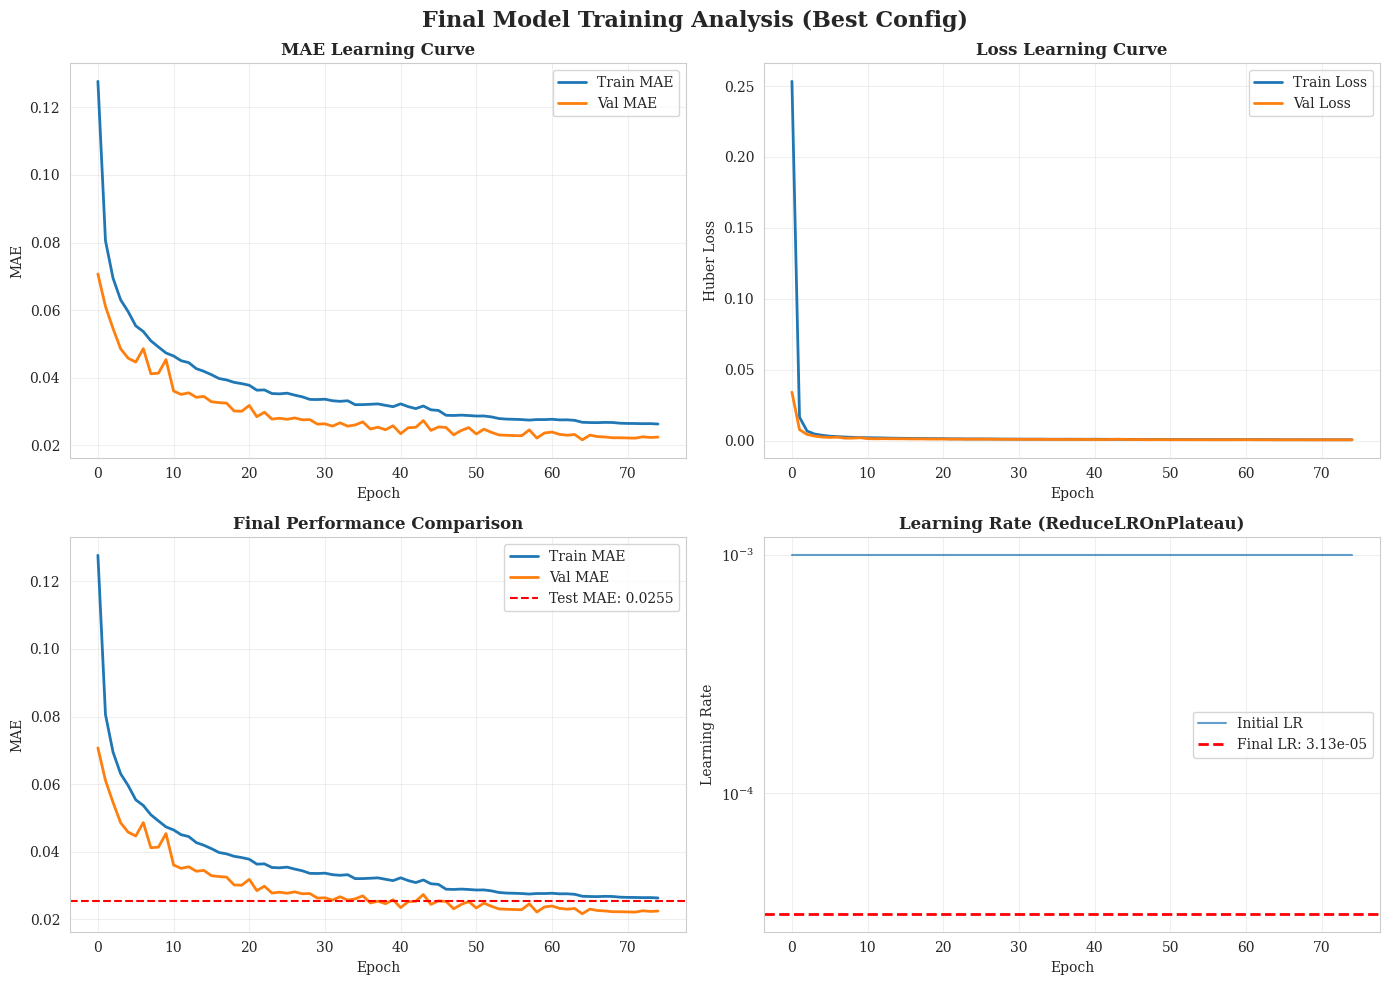


✅ Training complete! Model saved as 'best_final_model.keras'

📈 Plots saved: learning_curves_final_model.png
🎯 Final Test Performance: MAE=0.0255, R²=0.9740


In [ ]:
# =============================================================================
# FINAL MODEL TRAINING WITH BEST HYPERPARAMETERS + LEARNING CURVES
# Uses: LSTM=128, Dropout=0.2, Attention=4 heads, key_dim=64
# =============================================================================
SEED = 22
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# Run comprehensive comparison
(X_train, dec_train, y_train,
 X_val, dec_val, y_val,
 X_test, dec_test, y_test,
 scalers, feature_cols) = prepare_enhanced_data(df)
# 1. BEST CONFIGURATION (from your hyperparameter search)
BEST_CONFIG = {
    'lstm_units': 128,
    'dropout_rate': 0.2,
    'num_heads': 4,
    'key_dim': 64,
    'dense_units': 32,
    'l2_reg': 0.001,
    'learning_rate': 0.001
}

print("🎯 Training FINAL MODEL with best hyperparameters:")
print(f"   LSTM units: {BEST_CONFIG['lstm_units']}")
print(f"   Dropout: {BEST_CONFIG['dropout_rate']}")
print(f"   Attention: {BEST_CONFIG['num_heads']}h, key_dim={BEST_CONFIG['key_dim']}")

# 2. CREATE MODEL WITH BEST PARAMS
model = create_enhanced_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    output_steps=y_train.shape[1],
    num_features=X_train.shape[2],
    lstm_units=BEST_CONFIG['lstm_units'],
    dense_units=BEST_CONFIG['dense_units'],
    dropout_rate=BEST_CONFIG['dropout_rate'],
    num_heads=BEST_CONFIG['num_heads'],
    key_dim=BEST_CONFIG['key_dim'],
    l2_reg=BEST_CONFIG['l2_reg'],
    learning_rate=BEST_CONFIG['learning_rate']
)

# 3. CALLBACKS (save history for plots)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=10, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_mae', factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint('best_final_model.keras', save_best_only=True)
]

# 4. TRAIN FINAL MODEL
print("\n🚀 Starting FINAL training...")
history = model.fit(
    [X_train, dec_train], y_train,
    validation_data=([X_val, dec_val], y_val),
    epochs=80,
    batch_size=64,  # Your original batch size
    callbacks=callbacks,
    verbose=1
)

# 5. EVALUATE FINAL PERFORMANCE
def evaluate_metrics(X, dec_input, y_true, scalers, prefix=""):
    y_pred = model.predict([X, dec_input], verbose=0)

    # Unscale predictions
    if 'target_scaler' in scalers:
        y_true_unscaled = scalers['target_scaler'].inverse_transform(y_true.reshape(-1, 1)).flatten()
        y_pred_unscaled = scalers['target_scaler'].inverse_transform(y_pred.reshape(-1, 1)).flatten()
    else:
        y_true_unscaled, y_pred_unscaled = y_true.flatten(), y_pred.flatten()

    mae = mean_absolute_error(y_true_unscaled, y_pred_unscaled)
    r2 = r2_score(y_true_unscaled, y_pred_unscaled)

    print(f"\n📊 {prefix} RESULTS:")
    print(f"   MAE: {mae:.4f}")
    print(f"   R²:  {r2:.4f}")

    return mae, r2

# Run evaluations
print("\n" + "="*60)
train_mae, train_r2 = evaluate_metrics(X_train, dec_train, y_train, scalers, "TRAIN")
val_mae, val_r2 = evaluate_metrics(X_val, dec_val, y_val, scalers, "VALIDATION")
test_mae, test_r2 = evaluate_metrics(X_test, dec_test, y_test, scalers, "TEST")
print("="*60)

# 6. LEARNING CURVES PLOTS (for your paper Fig 2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Final Model Training Analysis (Best Config)', fontsize=16, fontweight='bold')

# Plot 1: MAE Learning Curve
axes[0,0].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[0,0].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[0,0].set_title('MAE Learning Curve', fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('MAE')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Loss Learning Curve
axes[0,1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0,1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0,1].set_title('Loss Learning Curve', fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Huber Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: R² Over Epochs (approximate from MAE)
axes[1,0].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1,0].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1,0].axhline(y=test_mae, color='r', linestyle='--', label=f'Test MAE: {test_mae:.4f}')
axes[1,0].set_title('Final Performance Comparison', fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('MAE')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: FIXED Learning Rate Schedule (no 'lr' key in history)
lr_history = [BEST_CONFIG['learning_rate']] * len(history.history['loss'])  # Constant LR
current_lr = model.optimizer.learning_rate.numpy() if hasattr(model.optimizer.learning_rate, 'numpy') else BEST_CONFIG['learning_rate']

axes[1,1].plot(lr_history, label='Initial LR', alpha=0.7)
axes[1,1].axhline(y=current_lr, color='red', linestyle='--', linewidth=2, label=f'Final LR: {current_lr:.2e}')
axes[1,1].set_title('Learning Rate (ReduceLROnPlateau)', fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Learning Rate')
axes[1,1].set_yscale('log')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_final_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Training complete! Model saved as 'best_final_model.keras'")
print(f"\n📈 Plots saved: learning_curves_final_model.png")
print(f"🎯 Final Test Performance: MAE={test_mae:.4f}, R²={test_r2:.4f}")


## 5. SHAP-Based Interpretability Analysis

SHAP (SHapley Additive exPlanations) values are computed via `KernelExplainer` using 100 background training samples. The analysis quantifies each feature's contribution to predictions across all 12 forecasting steps, providing local and global interpretability of the dual-attention model.

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
100%|██████████| 1/1 [04:23<00:00, 263.18s/it]

--- SHAP values for decoder step 0 ---


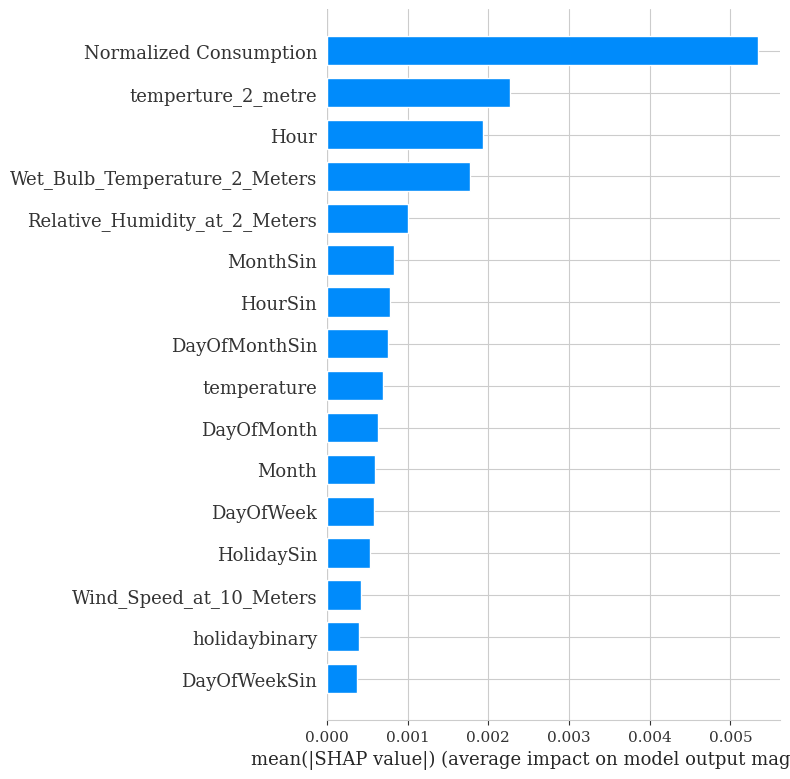

--- SHAP values for decoder step 1 ---


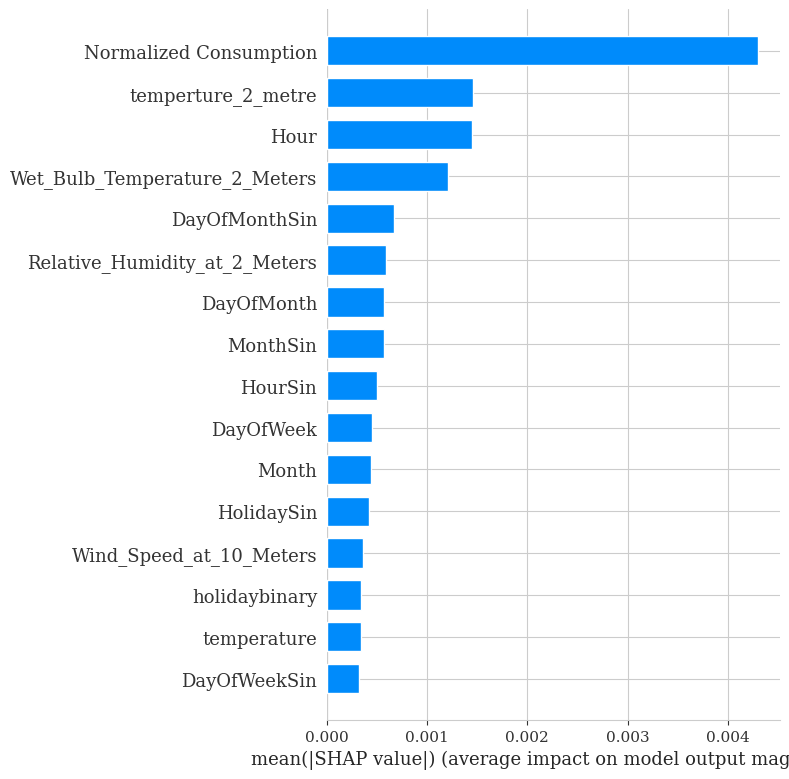

--- SHAP values for decoder step 2 ---


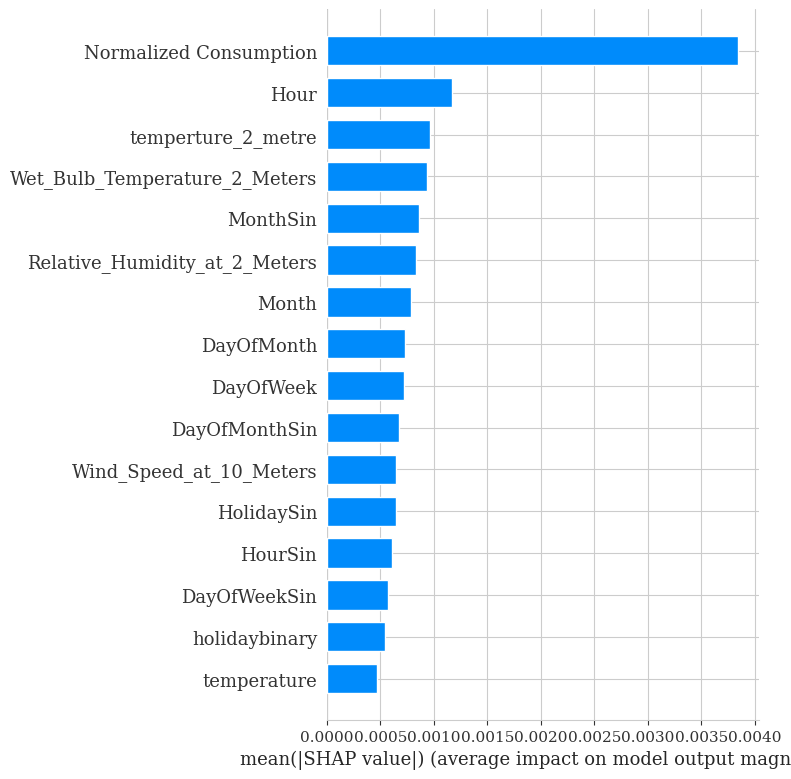

--- SHAP values for decoder step 3 ---


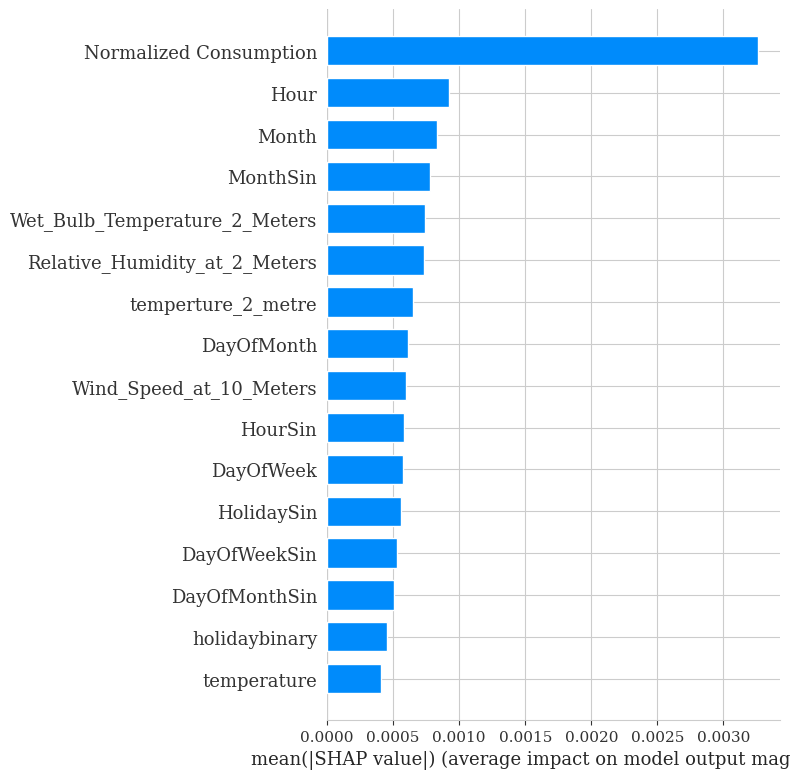

--- SHAP values for decoder step 4 ---


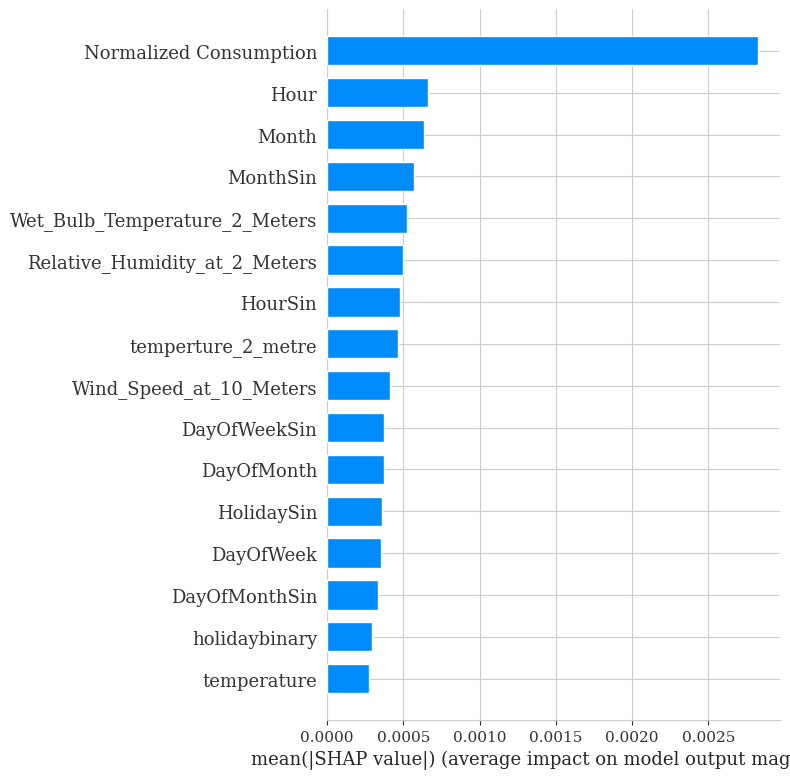

--- SHAP values for decoder step 5 ---


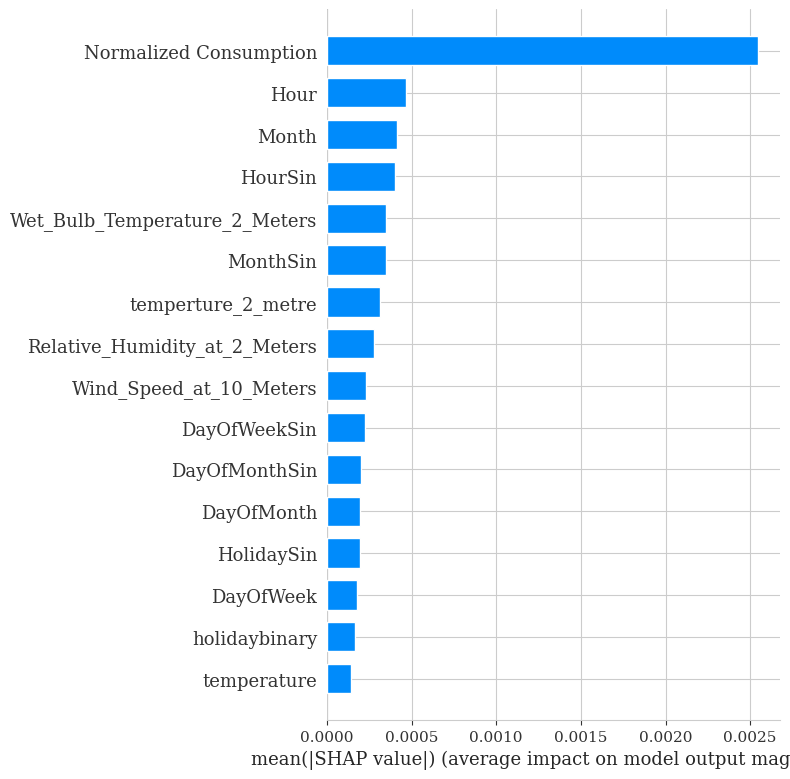

--- SHAP values for decoder step 6 ---


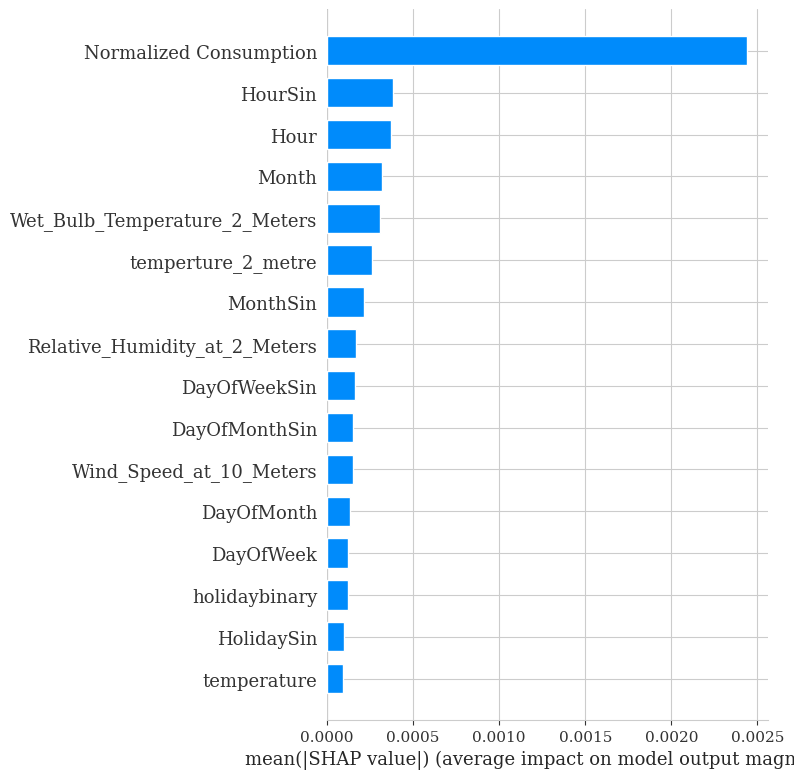

--- SHAP values for decoder step 7 ---


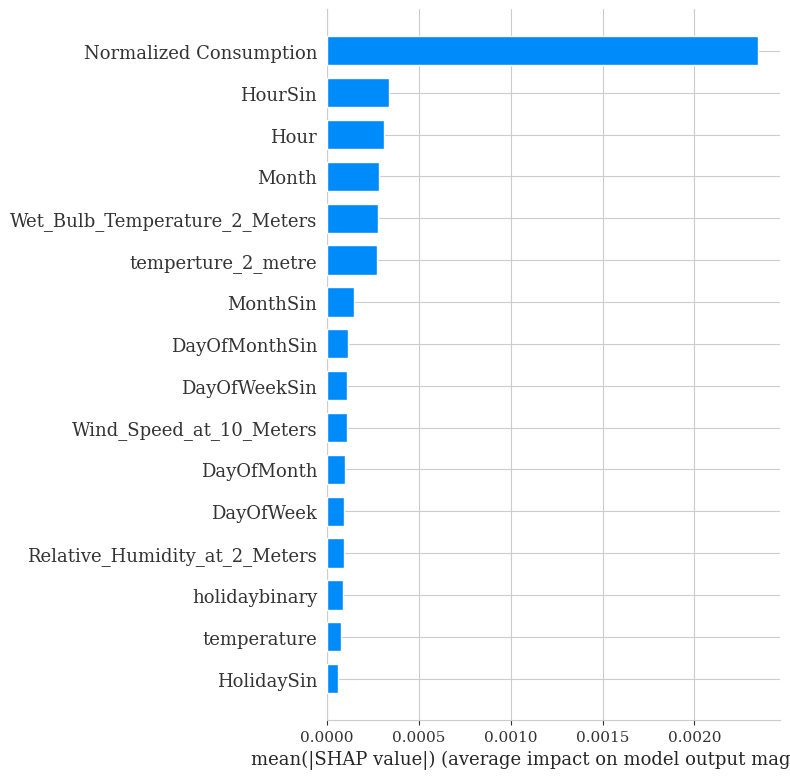

--- SHAP values for decoder step 8 ---


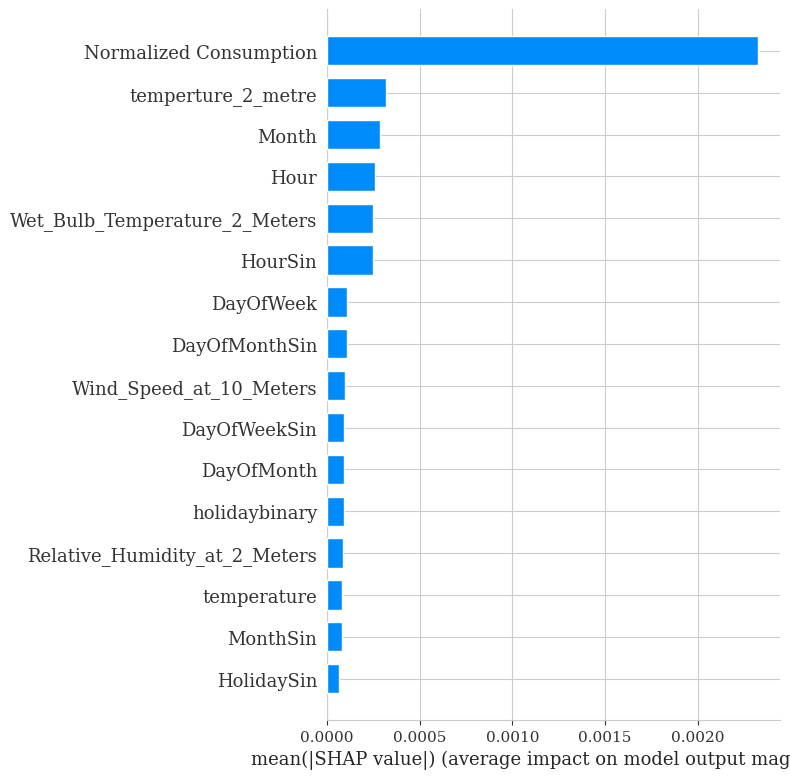

--- SHAP values for decoder step 9 ---


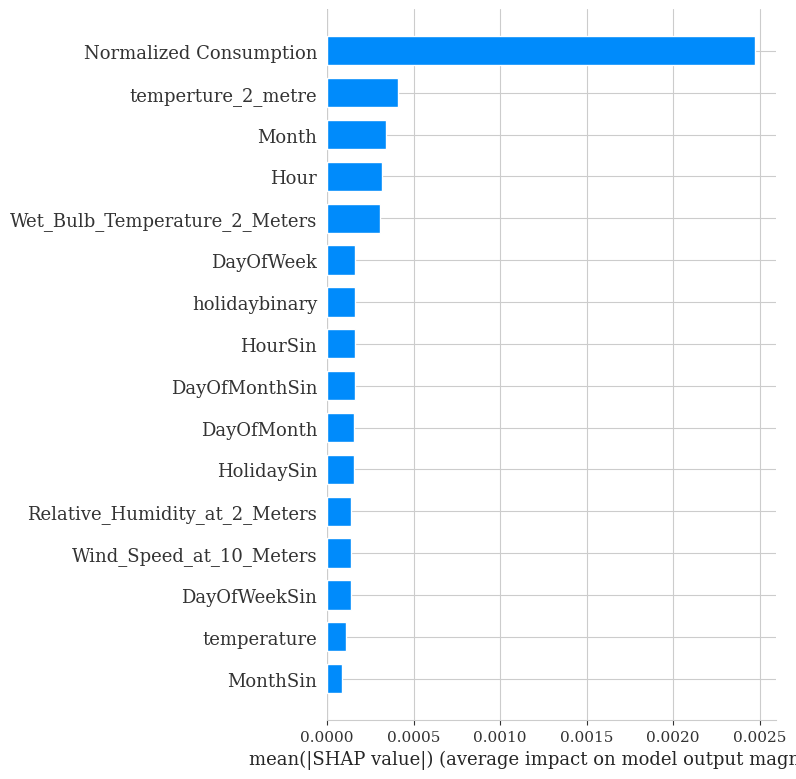

--- SHAP values for decoder step 10 ---


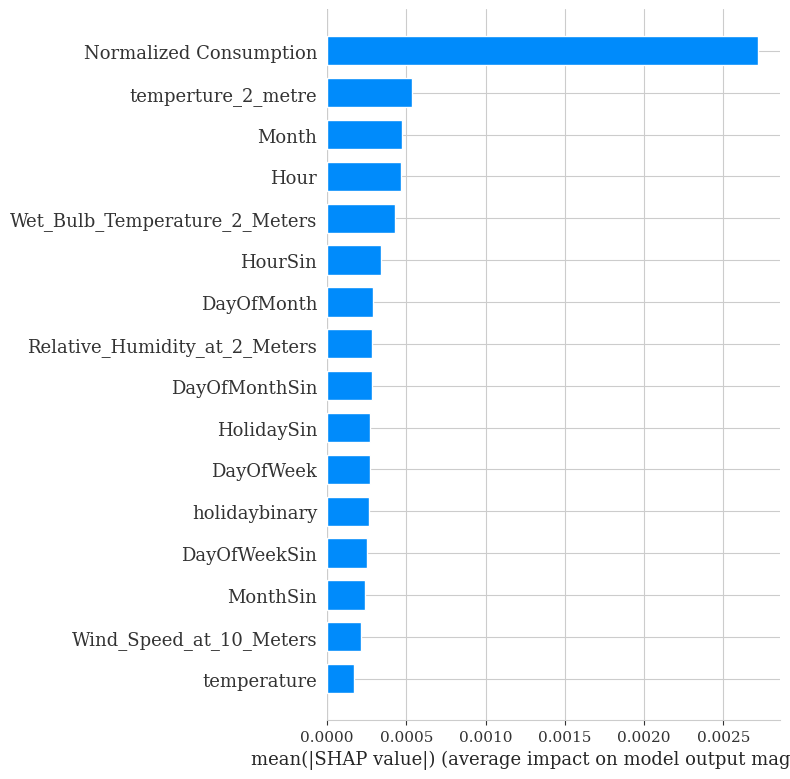

--- SHAP values for decoder step 11 ---


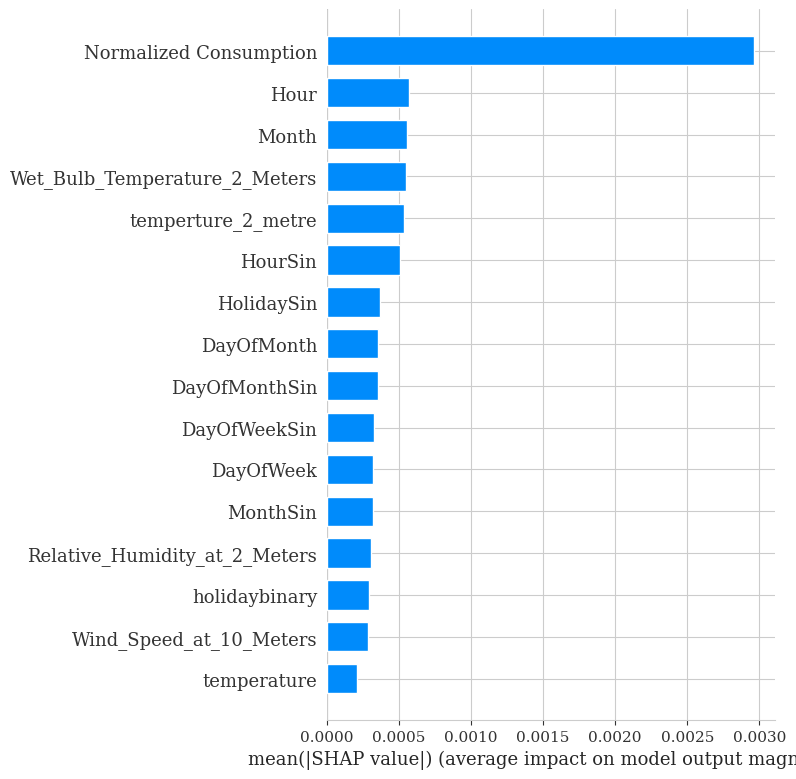

--- Aggregated SHAP values (mean over decoder steps) ---


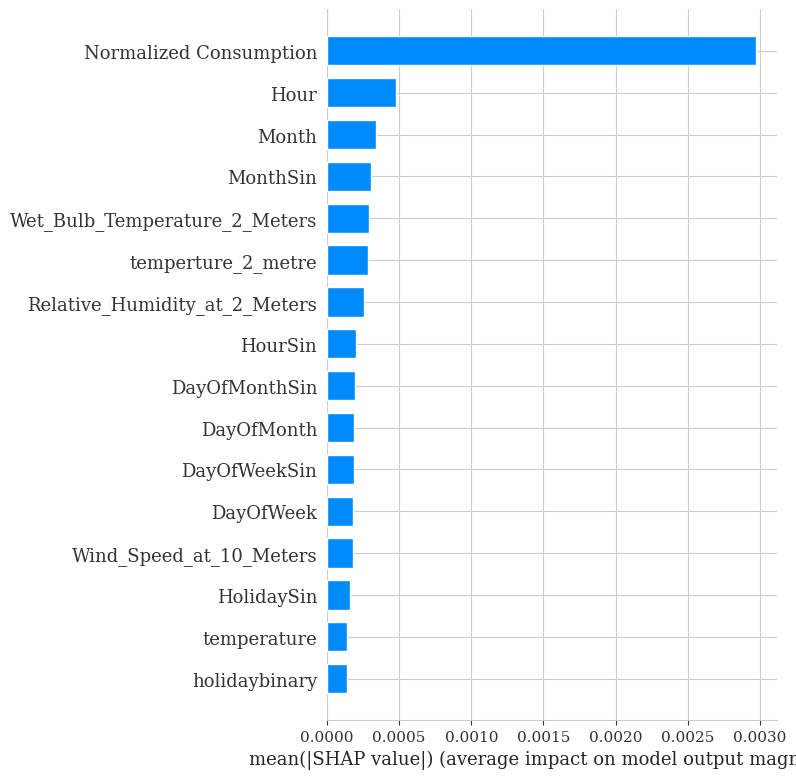

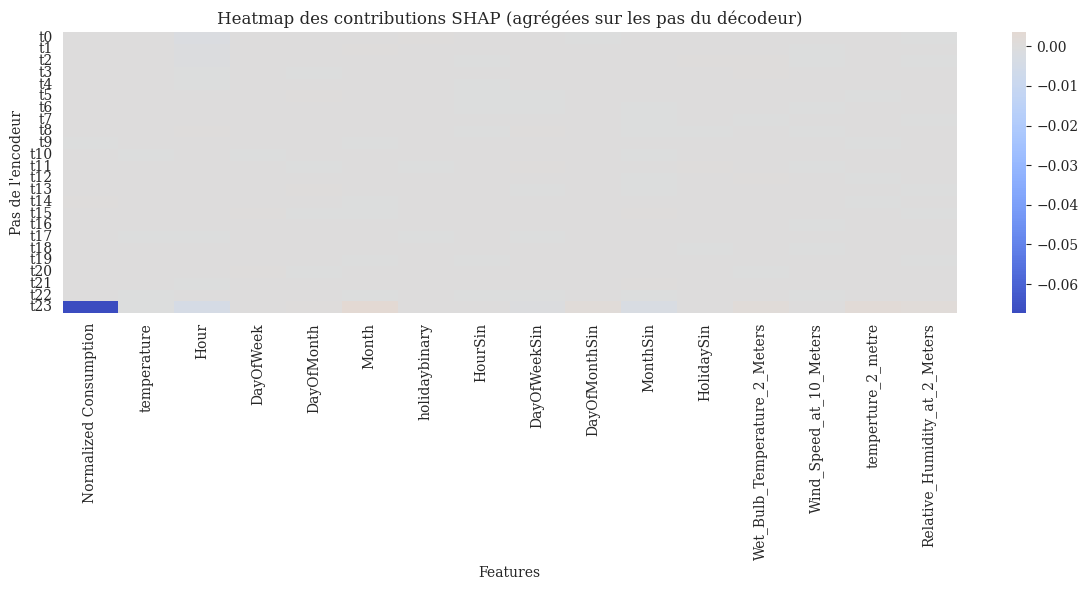

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Paramètres
# -------------------------
ENC_STEPS = 24
DEC_STEPS = 12
N_FEATURES = 16  # nombre de features par pas



# -------------------------
# 1️⃣ Wrapper pour SHAP
# -------------------------
def predict_wrapper(x_flat):
    """
    x_flat: (batch, ENC_STEPS * N_FEATURES)
    Retourne les sorties du décodeur aplaties pour SHAP.
    """
    batch_size = x_flat.shape[0]

    # Reshape flat encoder input
    x_enc = x_flat.reshape(batch_size, ENC_STEPS, N_FEATURES)

    # Initialiser entrée du décodeur
    dec_input = np.zeros((batch_size, DEC_STEPS, N_FEATURES))
    dec_input[:, 0, :] = x_enc[:, -1, :]  # teacher forcing placeholder

    # Prédiction
    y_pred = model.predict([x_enc, dec_input], verbose=0)  # (batch, DEC_STEPS, 1)

    return y_pred.reshape(batch_size, -1)  # (batch, DEC_STEPS)

# -------------------------
# 2️⃣ Données de fond et sample
# -------------------------
background_data = X_train[:100].reshape(100, ENC_STEPS * N_FEATURES)
sample_idx = 0
sample_to_explain = X_test[sample_idx:sample_idx+1].reshape(1, ENC_STEPS * N_FEATURES)

# -------------------------
# 3️⃣ Initialiser KernelExplainer
# -------------------------
explainer = shap.KernelExplainer(
    model=predict_wrapper,
    data=background_data,
    link="identity"
)

# -------------------------
# 4️⃣ Calculer SHAP values
# -------------------------
shap_values = explainer.shap_values(sample_to_explain)

# -------------------------
# 5️⃣ Fonction générique de visualisation
# -------------------------
def visualize_shap_values(shap_values, ENC_STEPS, N_FEATURES, feature_cols, mode="per_step"):
    """
    shap_values : liste renvoyée par explainer.shap_values(sample)
                  → longueur = DEC_STEPS, chaque élément = (1, ENC_STEPS * N_FEATURES)
    mode        : "per_step" → un plot par pas de sortie
                  "mean"     → agrégation moyenne sur tous les pas
    """

    if mode == "per_step":
        for t, sv in enumerate(shap_values):
            shap_values_t = sv.reshape(ENC_STEPS, N_FEATURES)
            print(f"--- SHAP values for decoder step {t} ---")
            shap.summary_plot(
                shap_values_t,
                feature_names=feature_cols,
                plot_type="bar",
                max_display=20
            )

    elif mode == "mean":
        shap_values_mean = np.mean([sv for sv in shap_values], axis=0)
        shap_values_reshaped = shap_values_mean.reshape(ENC_STEPS, N_FEATURES)
        print("--- Aggregated SHAP values (mean over decoder steps) ---")
        shap.summary_plot(
            shap_values_reshaped,
            feature_names=feature_cols,
            plot_type="bar",
            max_display=20
        )
    else:
        raise ValueError("mode must be 'per_step' or 'mean'")

# -------------------------
# 6️⃣ Heatmap pour visualisation temps × features
# -------------------------
def plot_shap_heatmap(shap_values, ENC_STEPS, N_FEATURES, feature_cols):
    """
    Agrège les shap_values sur tous les pas de sortie et affiche une heatmap
    (ENC_STEPS × N_FEATURES).
    """
    shap_values_mean = np.mean([sv for sv in shap_values], axis=0)
    shap_values_reshaped = shap_values_mean.reshape(ENC_STEPS, N_FEATURES)

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        shap_values_reshaped,
        xticklabels=feature_cols,
        yticklabels=[f"t{t}" for t in range(ENC_STEPS)],
        cmap="coolwarm",
        center=0
    )
    plt.title("Heatmap des contributions SHAP (agrégées sur les pas du décodeur)")
    plt.xlabel("Features")
    plt.ylabel("Pas de l'encodeur")
    plt.tight_layout()
    plt.show()

# -------------------------
# 7️⃣ Appels
# -------------------------
# Visualisation par pas de sortie
visualize_shap_values(shap_values, ENC_STEPS, N_FEATURES, feature_cols, mode="per_step")

# Visualisation agrégée
visualize_shap_values(shap_values, ENC_STEPS, N_FEATURES, feature_cols, mode="mean")

# Heatmap
plot_shap_heatmap(shap_values, ENC_STEPS, N_FEATURES, feature_cols)


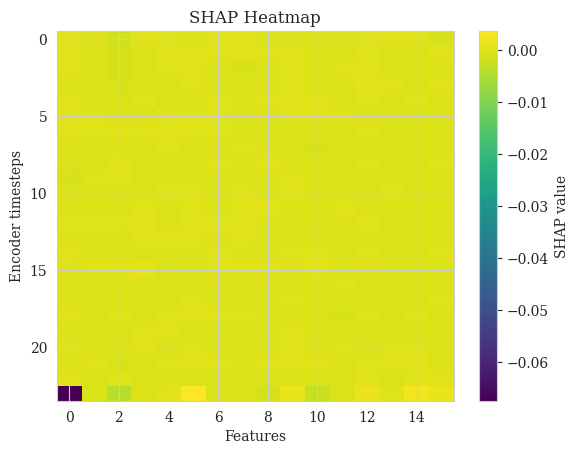

In [ ]:
import matplotlib.pyplot as plt
shap_values_mean = np.mean([sv for sv in shap_values], axis=0)
shap_values_reshaped = shap_values_mean.reshape(ENC_STEPS, N_FEATURES)
plt.imshow(shap_values_reshaped, aspect='auto', cmap='viridis')
plt.colorbar(label='SHAP value')
plt.xlabel('Features')
plt.ylabel('Encoder timesteps')
plt.title('SHAP Heatmap')
plt.show()


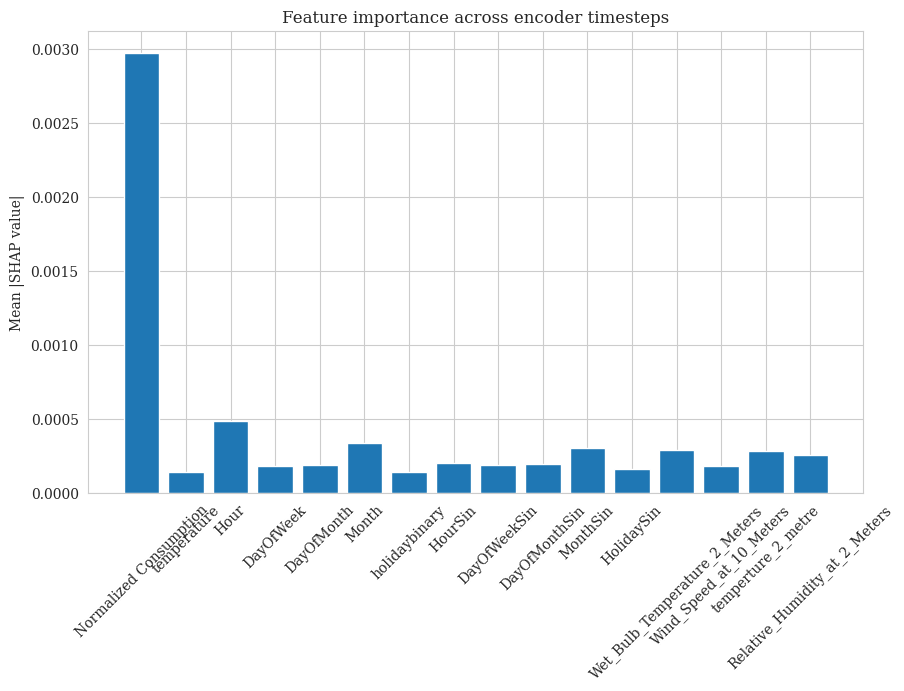

In [ ]:
import shap
import numpy as np

# Average absolute SHAP value per feature across timesteps
feature_importance = np.mean(np.abs(shap_values_reshaped), axis=0)  # (N_FEATURES,)

# Bar plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(range(N_FEATURES), feature_importance)
plt.xticks(range(N_FEATURES), feature_cols, rotation=45)
plt.ylabel("Mean |SHAP value|")
plt.title("Feature importance across encoder timesteps")
plt.show()


66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
70.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
54.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
62.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.


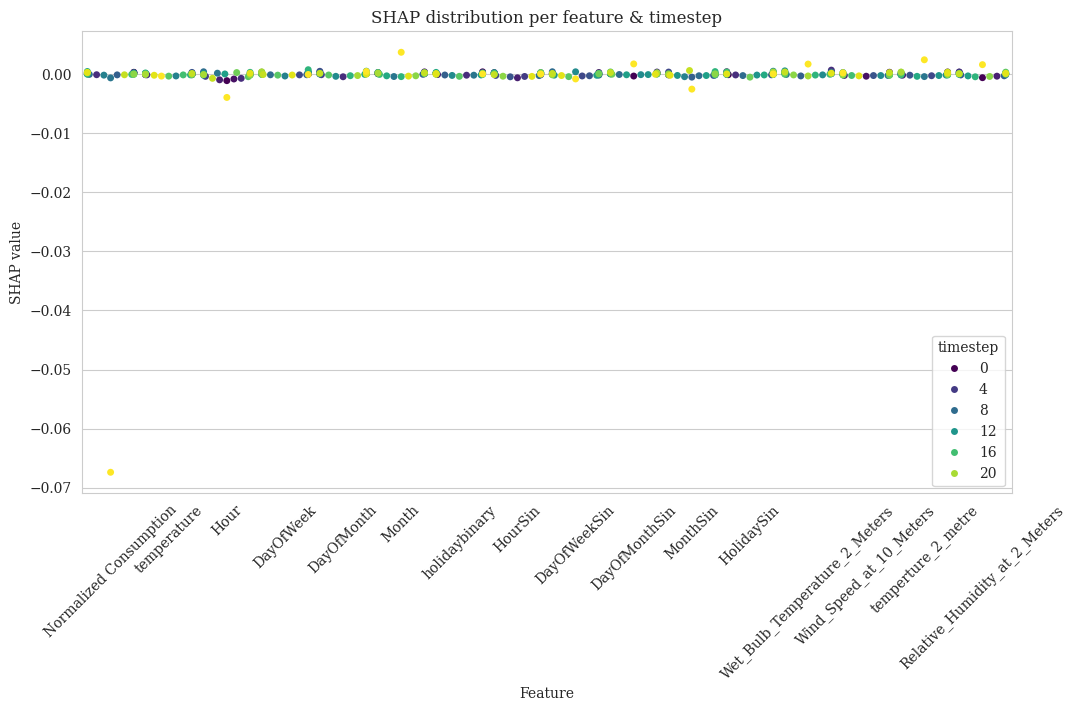

In [ ]:
# Flatten SHAP values for seaborn-friendly format
import pandas as pd
import seaborn as sns

timesteps, features = shap_values_reshaped.shape
df = pd.DataFrame(shap_values_reshaped, columns=feature_cols)
df['timestep'] = range(timesteps)

# Melt for plotting
df_melt = df.melt(id_vars='timestep', var_name='Feature', value_name='SHAP value')

plt.figure(figsize=(12,6))
sns.swarmplot(x='Feature', y='SHAP value', hue='timestep', data=df_melt, palette='viridis')
plt.xticks(rotation=45)
plt.title("SHAP distribution per feature & timestep")
plt.show()


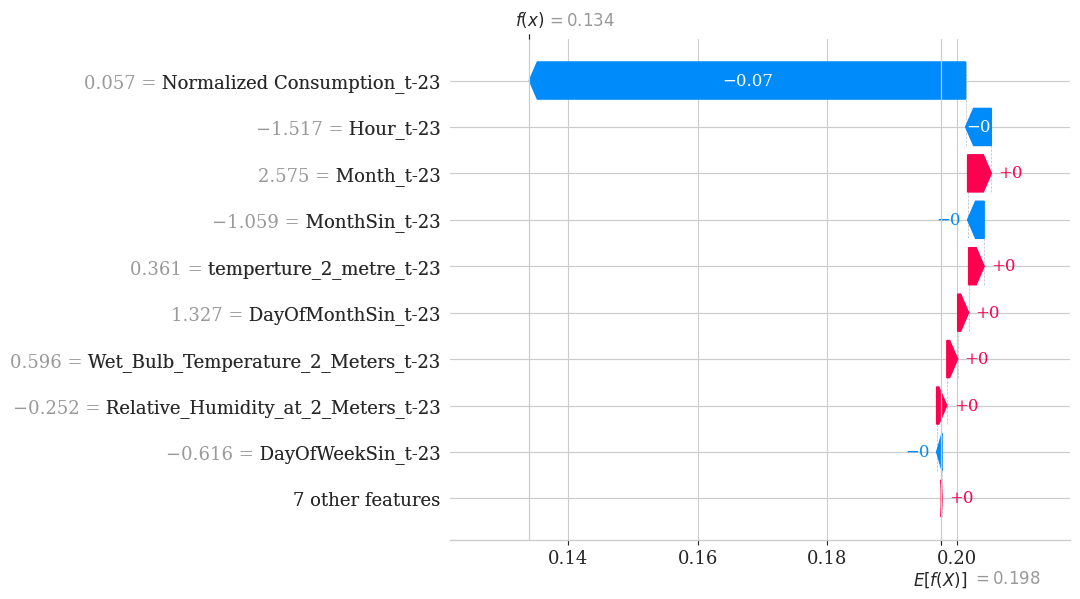

In [ ]:
# For the first prediction's last timestep
shap.plots.waterfall(shap.Explanation(
    values=shap_values_reshaped[-1].flatten(),
    base_values=explainer.expected_value[0],
    data=X_test[2, -1].flatten(),
    feature_names=[f"{f}_t-{23}" for f in feature_cols]
))


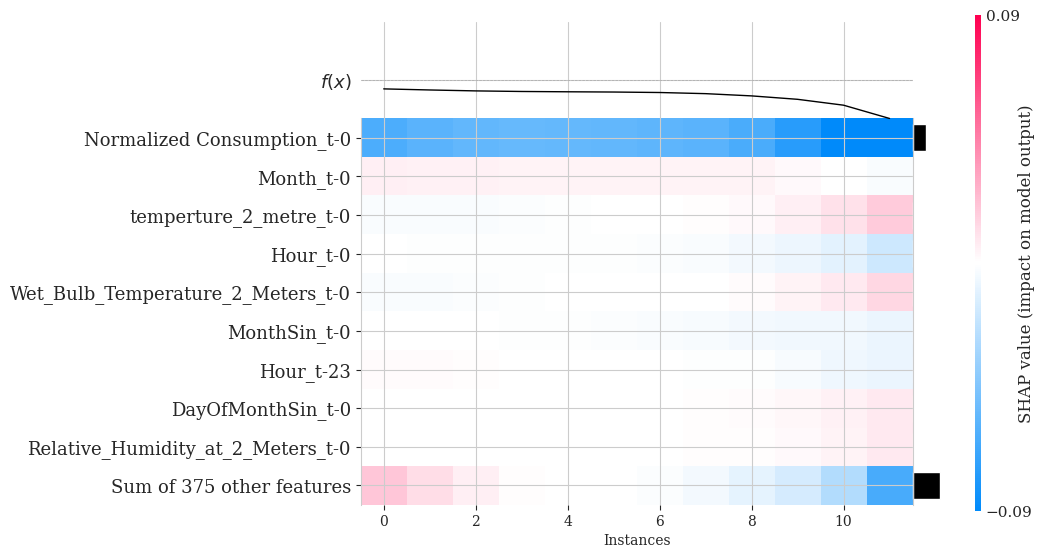

In [ ]:
shap.plots.heatmap(
    shap.Explanation(
        values=np.array(shap_values).reshape(-1, 24*16),
        base_values=explainer.expected_value[0],
        data=X_test[:2].reshape(1, -1),
        feature_names=[f"{f}_t-{t}" for t in range(23,-1,-1) for f in feature_cols]
    ),
    show=False
)
#plt.title('SHAP Value Clustering Heatmap')


In [ ]:
shap.initjs()
html_force_plot = shap.force_plot(
    explainer.expected_value[0],
    shap_values_reshaped.reshape(-1),
    X_test[20].reshape(-1),
    feature_names=[f"{f}_t-{t}" for t in range(23,-1,-1) for f in feature_cols],
    link="identity"
)
display(html_force_plot)

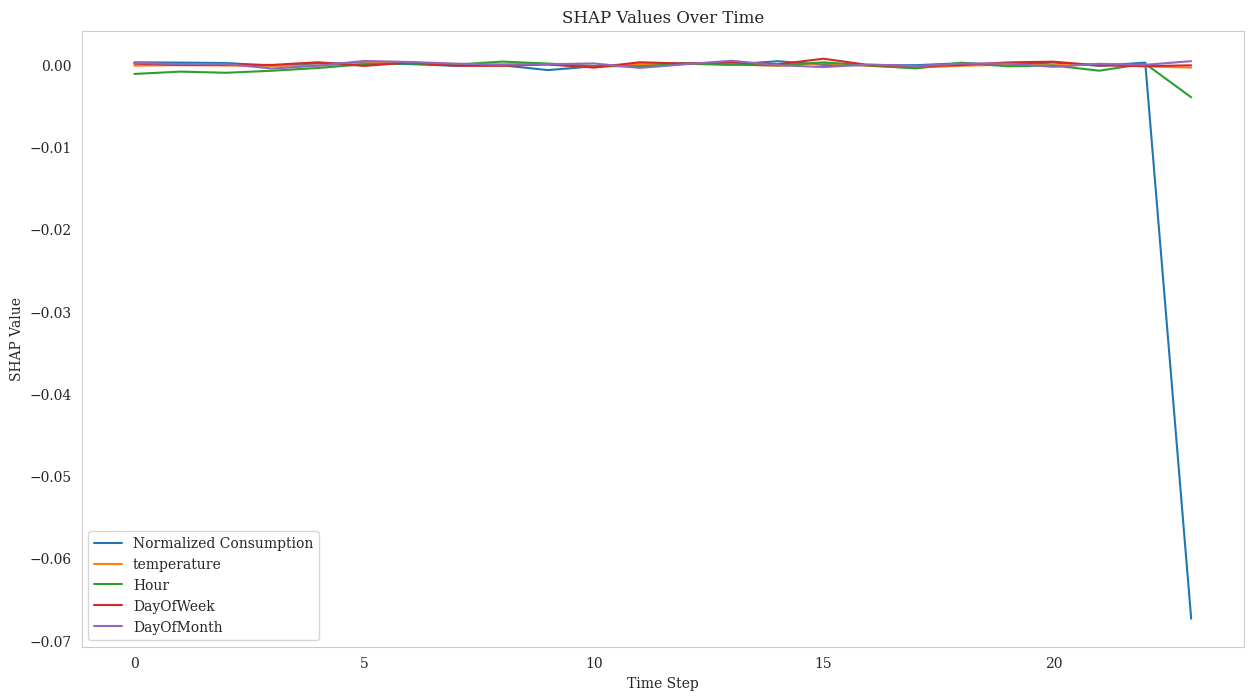

In [ ]:
# Reshape to (timesteps, features)
shap_matrix = shap_values_reshaped

plt.figure(figsize=(15, 8))
for i, feature in enumerate(feature_cols[:5]):  # Top 10 features
    plt.plot(shap_matrix[:, i], label=feature)

plt.xlabel("Time Step")
plt.ylabel("SHAP Value")
plt.title("SHAP Values Over Time")
plt.legend()
plt.grid()
plt.show()

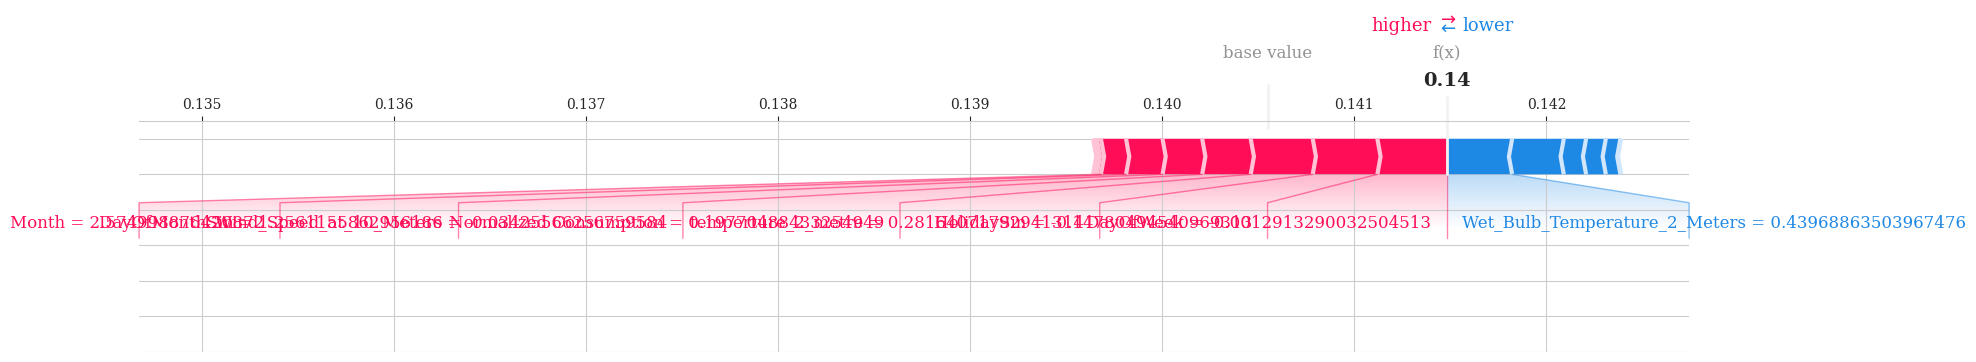

In [ ]:
timestep_to_show = -4  # Most recent timestep
shap.force_plot(
    explainer.expected_value[1],
    shap_values_reshaped[timestep_to_show],
    X_test[0, timestep_to_show],
    feature_names=feature_cols,
    matplotlib=True
)
#plt.title(f"Force Plot for Time Step {timestep_to_show}")


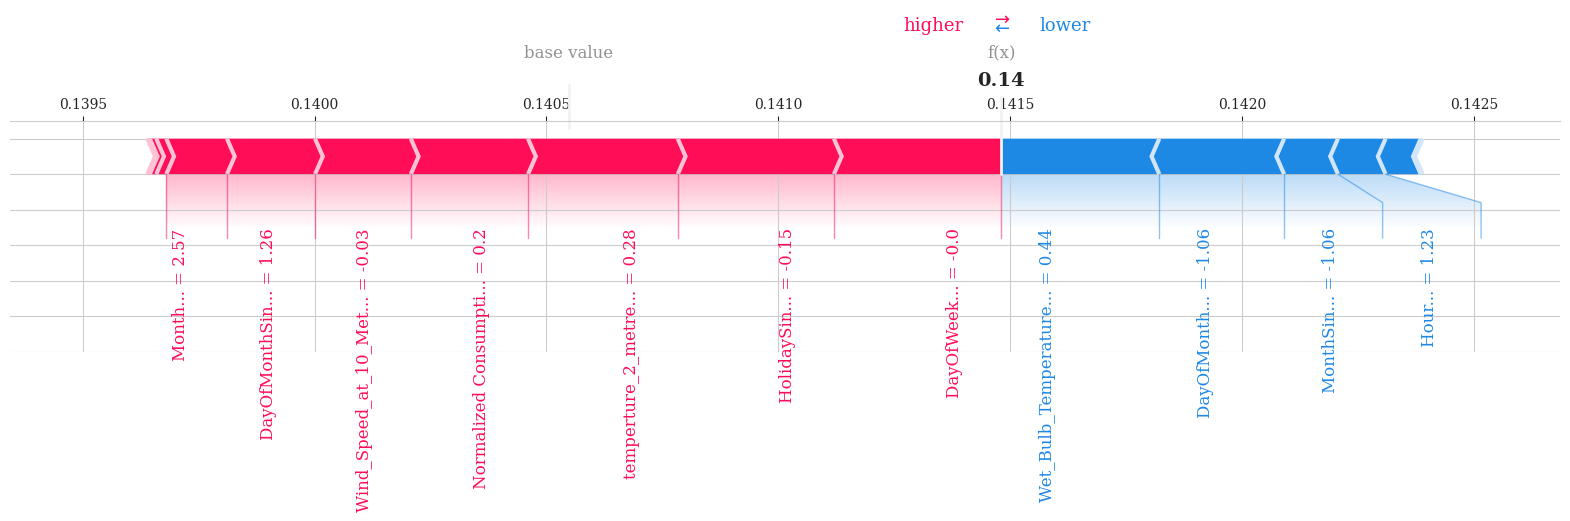

In [ ]:


shap.force_plot(
    explainer.expected_value[1],
    shap_values_reshaped[timestep_to_show],
    np.round(X_test[0, timestep_to_show], 2),
    feature_names=[f"{n[:20]}..." for n in feature_cols],  # Shorten long names
    text_rotation=90,
    contribution_threshold=0.05,  # Only show significant contributions
    matplotlib=True
)

# Comprehensive suite of baseline and comparison models for energy forecasting.
  All models use the same data format as our model for fair comparison

In [ ]:
df=pd.read_csv('new_data_temp.csv')


COMPREHENSIVE MODEL COMPARISON

📊 STATISTICAL BASELINES

Testing: Naive Forecast

──────────────────────────────────────────────────────────────────────
Results for Naive Forecast:
  MAE:   0.0734
  RMSE:  0.1000
  R²:    0.7791
  MAPE:  20.23%
  Time:  0.0s (0.0 min)
  Params: 0
──────────────────────────────────────────────────────────────────────


Testing: Moving Average

──────────────────────────────────────────────────────────────────────
Results for Moving Average:
  MAE:   0.0731
  RMSE:  0.1044
  R²:    0.7594
  MAPE:  19.54%
  Time:  0.0s (0.0 min)
  Params: 0
──────────────────────────────────────────────────────────────────────


Testing: Seasonal Naive

──────────────────────────────────────────────────────────────────────
Results for Seasonal Naive:
  MAE:   0.1042
  RMSE:  0.1523
  R²:    0.4881
  MAPE:  27.91%
  Time:  0.0s (0.0 min)
  Params: 0
──────────────────────────────────────────────────────────────────────


🤖 MACHINE LEARNING MODELS

Testing: Random Forest



Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



──────────────────────────────────────────────────────────────────────
Results for Vanilla LSTM:
  MAE:   0.1392
  RMSE:  0.1848
  R²:    0.2467
  MAPE:  30.51%
  Time:  65.7s (1.1 min)
  Params: 124,428
──────────────────────────────────────────────────────────────────────


Testing: GRU


Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



──────────────────────────────────────────────────────────────────────
Results for GRU:
  MAE:   0.1036
  RMSE:  0.1348
  R²:    0.5991
  MAPE:  23.56%
  Time:  102.2s (1.7 min)
  Params: 94,092
──────────────────────────────────────────────────────────────────────


Testing: BiLSTM


Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



──────────────────────────────────────────────────────────────────────
Results for BiLSTM:
  MAE:   0.2071
  RMSE:  0.2586
  R²:    -0.4752
  MAPE:  43.91%
  Time:  89.2s (1.5 min)
  Params: 83,468
──────────────────────────────────────────────────────────────────────


Testing: CNN-LSTM


Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



──────────────────────────────────────────────────────────────────────
Results for CNN-LSTM:
  MAE:   0.1318
  RMSE:  0.1744
  R²:    0.3286
  MAPE:  34.22%
  Time:  15.8s (0.3 min)
  Params: 34,924
──────────────────────────────────────────────────────────────────────


Testing: Attention-LSTM

──────────────────────────────────────────────────────────────────────
Results for Attention-LSTM:
  MAE:   0.2224
  RMSE:  0.2716
  R²:    -0.6280
  MAPE:  45.08%
  Time:  107.0s (1.8 min)
  Params: 141,292
──────────────────────────────────────────────────────────────────────


Testing: Transformer

──────────────────────────────────────────────────────────────────────
Results for Transformer:
  MAE:   0.1205
  RMSE:  0.1524
  R²:    0.4877
  MAPE:  29.62%
  Time:  43.1s (0.7 min)
  Params: 20,972
──────────────────────────────────────────────────────────────────────


Testing: Seq2Seq Basic


The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_4']. Received: the structure of inputs=('*', '*')



──────────────────────────────────────────────────────────────────────
Results for Seq2Seq Basic:
  MAE:   0.0756
  RMSE:  0.0974
  R²:    0.7908
  MAPE:  17.45%
  Time:  90.4s (1.5 min)
  Params: 148,609
──────────────────────────────────────────────────────────────────────


✅ Results saved to model_comparison_results.csv

✅ Comparison plot saved to model_comparison.png


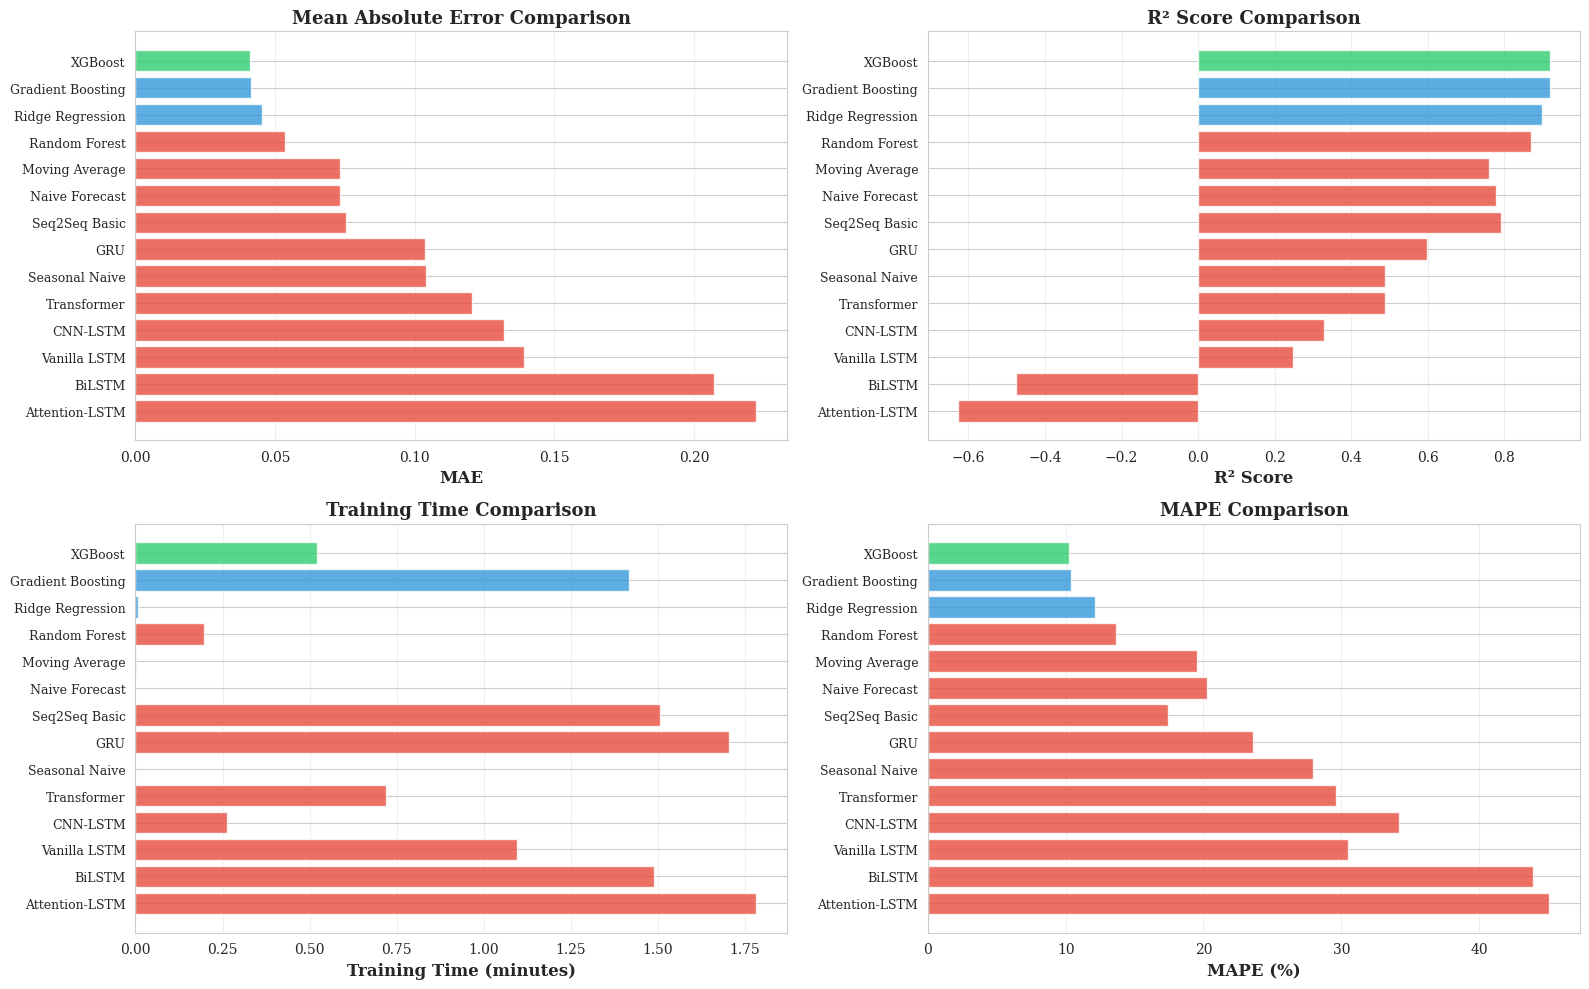


FINAL RANKING
            model      mae        r2  training_time
          XGBoost 0.041128  0.920031      31.219695
Gradient Boosting 0.041490  0.919051      85.079827
 Ridge Regression 0.045379  0.898514       0.471361
    Random Forest 0.053681  0.869184      11.802573
   Moving Average 0.073142  0.759363       0.006981
   Naive Forecast 0.073406  0.779146       0.001460
    Seq2Seq Basic 0.075561  0.790812      90.396093
              GRU 0.103570  0.599089     102.218214
   Seasonal Naive 0.104173  0.488141       0.000997
      Transformer 0.120479  0.487687      43.089195
         CNN-LSTM 0.131821  0.328598      15.762140
     Vanilla LSTM 0.139208  0.246701      65.746187
           BiLSTM 0.207071 -0.475235      89.243106
   Attention-LSTM 0.222403 -0.628042     106.951350


In [ ]:
"""
Comprehensive suite of baseline and comparison models for energy forecasting.
All models use the same data format as your enhanced model for fair comparison.
"""

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten,
    GRU, Bidirectional, Concatenate, RepeatVector, TimeDistributed,
    MultiHeadAttention, LayerNormalization, Add
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.regularizers import l2
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from datetime import datetime
import matplotlib.pyplot as plt


# ============================================================================
# 1. STATISTICAL BASELINE MODELS
# ============================================================================

class StatisticalModels:
    """Traditional statistical forecasting models."""

    @staticmethod
    def naive_forecast(X_train, y_train, X_test):
        """
        Naive forecast: last observed value persistence.
        """
        # Use last value from each sequence
        predictions = X_train[:, -1, 0]  # Last timestep, first feature (consumption)
        # Repeat for all output steps
        y_pred = np.tile(predictions.reshape(-1, 1, 1), (1, y_train.shape[1], 1))

        # For test set
        test_predictions = X_test[:, -1, 0]
        y_test_pred = np.tile(test_predictions.reshape(-1, 1, 1), (1, y_train.shape[1], 1))

        return y_test_pred

    @staticmethod
    def moving_average_forecast(X_train, y_train, X_test, window=24):
        """
        Moving average forecast.
        """
        def compute_ma(X, window):
            predictions = []
            for sample in X:
                # Use consumption feature (assumed to be first column)
                consumption = sample[:, 0]
                ma = np.convolve(consumption, np.ones(window)/window, mode='valid')[-1]
                predictions.append(ma)
            return np.array(predictions)

        test_ma = compute_ma(X_test, window)
        y_test_pred = np.tile(test_ma.reshape(-1, 1, 1), (1, y_train.shape[1], 1))

        return y_test_pred

    @staticmethod
    def seasonal_naive(X_train, y_train, X_test, seasonal_period=24):
        """
        Seasonal naive: use value from same time last period.
        """
        predictions = []
        for sample in X_test:
            # Get value from seasonal_period steps ago
            if len(sample) >= seasonal_period:
                seasonal_val = sample[-seasonal_period, 0]
            else:
                seasonal_val = sample[-1, 0]
            predictions.append(seasonal_val)

        y_test_pred = np.tile(np.array(predictions).reshape(-1, 1, 1),
                              (1, y_train.shape[1], 1))
        return y_test_pred


# ============================================================================
# 2. MACHINE LEARNING MODELS
# ============================================================================

class MLModels:
    """Machine learning regression models."""

    @staticmethod
    def prepare_ml_data(X, y):
        """Flatten sequential data for ML models."""
        # X shape: (samples, timesteps, features)
        # y shape: (samples, output_steps, 1)
        X_flat = X.reshape(X.shape[0], -1)  # (samples, timesteps*features)
        y_flat = y.reshape(y.shape[0], -1)  # (samples, output_steps)
        return X_flat, y_flat

    @staticmethod
    def reshape_ml_predictions(y_pred, original_shape):
        """Reshape ML predictions back to (samples, output_steps, 1)."""
        return y_pred.reshape(original_shape[0], original_shape[1], 1)

    @staticmethod
    def random_forest(X_train, y_train, X_test, y_test):
        """Random Forest Regressor."""
        print("\n🌲 Training Random Forest...")

        X_train_flat, y_train_flat = MLModels.prepare_ml_data(X_train, y_train)
        X_test_flat, _ = MLModels.prepare_ml_data(X_test, y_test)

        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_split=5,
            n_jobs=-1,
            random_state=42
        )

        model.fit(X_train_flat, y_train_flat)
        y_pred = model.predict(X_test_flat)
        y_pred = MLModels.reshape_ml_predictions(y_pred, y_test.shape)

        return y_pred, model

    @staticmethod
    def xgboost(X_train, y_train, X_test, y_test):
        """XGBoost Regressor."""
        print("\n🚀 Training XGBoost...")

        X_train_flat, y_train_flat = MLModels.prepare_ml_data(X_train, y_train)
        X_test_flat, _ = MLModels.prepare_ml_data(X_test, y_test)

        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=7,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=-1,
            random_state=42
        )

        model.fit(X_train_flat, y_train_flat)
        y_pred = model.predict(X_test_flat)
        y_pred = MLModels.reshape_ml_predictions(y_pred, y_test.shape)

        return y_pred, model

    @staticmethod
    def gradient_boosting(X_train, y_train, X_test, y_test):
        """Gradient Boosting Regressor."""
        print("\n📈 Training Gradient Boosting...")

        X_train_flat, y_train_flat = MLModels.prepare_ml_data(X_train, y_train)
        X_test_flat, _ = MLModels.prepare_ml_data(X_test, y_test)

        # Train separate model for each output step (MultiOutputRegressor approach)
        from sklearn.multioutput import MultiOutputRegressor

        base_model = GradientBoostingRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        )

        model = MultiOutputRegressor(base_model, n_jobs=-1)
        model.fit(X_train_flat, y_train_flat)
        y_pred = model.predict(X_test_flat)
        y_pred = MLModels.reshape_ml_predictions(y_pred, y_test.shape)

        return y_pred, model

    @staticmethod
    def ridge_regression(X_train, y_train, X_test, y_test):
        """Ridge Regression (L2 regularization)."""
        print("\n📊 Training Ridge Regression...")

        X_train_flat, y_train_flat = MLModels.prepare_ml_data(X_train, y_train)
        X_test_flat, _ = MLModels.prepare_ml_data(X_test, y_test)

        from sklearn.multioutput import MultiOutputRegressor

        model = MultiOutputRegressor(Ridge(alpha=1.0), n_jobs=-1)
        model.fit(X_train_flat, y_train_flat)
        y_pred = model.predict(X_test_flat)
        y_pred = MLModels.reshape_ml_predictions(y_pred, y_test.shape)

        return y_pred, model


# ============================================================================
# 3. DEEP LEARNING BASELINE MODELS
# ============================================================================

def create_vanilla_lstm(input_shape, output_steps):
    """Simple stacked LSTM baseline."""
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(output_steps),
        tf.keras.layers.Reshape((output_steps, 1))
    ], name="vanilla_lstm")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


def create_gru_model(input_shape, output_steps):
    """GRU-based model (lighter than LSTM)."""
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(output_steps),
        tf.keras.layers.Reshape((output_steps, 1))
    ], name="gru_model")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


def create_bilstm_model(input_shape, output_steps):
    """Bidirectional LSTM without attention."""
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.2),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(0.2),
        Dense(output_steps),
        tf.keras.layers.Reshape((output_steps, 1))
    ], name="bilstm_model")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


def create_cnn_lstm(input_shape, output_steps):
    """CNN-LSTM hybrid model."""
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, activation='relu'),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(output_steps),
        tf.keras.layers.Reshape((output_steps, 1))
    ], name="cnn_lstm")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


def create_attention_lstm(input_shape, output_steps):
    """LSTM with single attention layer (simpler than your dual-attention)."""
    inputs = Input(shape=input_shape)

    # LSTM layers
    x = LSTM(128, return_sequences=True)(inputs)
    x = Dropout(0.2)(x)

    # Single attention mechanism
    attn_out = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    attn_out = LayerNormalization()(attn_out)
    x = Add()([x, attn_out])

    # Output
    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(0.2)(x)
    x = Dense(output_steps)(x)
    outputs = tf.keras.layers.Reshape((output_steps, 1))(x)

    model = Model(inputs, outputs, name="attention_lstm")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


def create_seq2seq_basic(input_shape, output_steps, num_features):
    """Basic encoder-decoder without attention."""
    # Encoder
    encoder_input = Input(shape=input_shape)
    encoder = LSTM(128, return_state=True)
    encoder_outputs, state_h, state_c = encoder(encoder_input)
    encoder_states = [state_h, state_c]

    # Decoder
    decoder_input = Input(shape=(output_steps, num_features))
    decoder_lstm = LSTM(128, return_sequences=True)
    decoder_outputs = decoder_lstm(decoder_input, initial_state=encoder_states)
    decoder_outputs = Dropout(0.2)(decoder_outputs)
    decoder_outputs = TimeDistributed(Dense(1))(decoder_outputs)

    model = Model([encoder_input, decoder_input], decoder_outputs, name="seq2seq_basic")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


def create_transformer_encoder(input_shape, output_steps):
    """Transformer encoder-only model."""
    inputs = Input(shape=input_shape)

    # Multi-head attention
    attn1 = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    attn1 = LayerNormalization()(attn1)
    x = Add()([inputs, attn1])

    # Second attention block
    attn2 = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    attn2 = LayerNormalization()(attn2)
    x = Add()([x, attn2])

    # Feed-forward
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(output_steps)(x)
    outputs = tf.keras.layers.Reshape((output_steps, 1))(x)

    model = Model(inputs, outputs, name="transformer_encoder")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


# ============================================================================
# 4. MODEL COMPARISON FRAMEWORK
# ============================================================================

class ModelComparison:
    """Framework for comparing all models."""

    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test,
                 dec_train=None, dec_val=None, dec_test=None, scalers=None):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.dec_train = dec_train
        self.dec_val = dec_val
        self.dec_test = dec_test
        self.scalers = scalers
        self.results = []

    def evaluate_metrics(self, y_true, y_pred):
        """Calculate metrics with inverse scaling."""
        y_true_flat = y_true.reshape(-1)
        y_pred_flat = y_pred.reshape(-1)

        if self.scalers and 'target_scaler' in self.scalers:
            y_true_unscaled = self.scalers['target_scaler'].inverse_transform(
                y_true.reshape(-1, 1)
            ).flatten()
            y_pred_unscaled = self.scalers['target_scaler'].inverse_transform(
                y_pred.reshape(-1, 1)
            ).flatten()
        else:
            y_true_unscaled = y_true_flat
            y_pred_unscaled = y_pred_flat

        mae = mean_absolute_error(y_true_unscaled, y_pred_unscaled)
        mse = mean_squared_error(y_true_unscaled, y_pred_unscaled)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true_unscaled, y_pred_unscaled)

        # MAPE (avoid division by zero)
        epsilon = 1e-10
        mape = np.mean(np.abs((y_true_unscaled - y_pred_unscaled) /
                              (y_true_unscaled + epsilon))) * 100

        return mae, mse, rmse, r2, mape

    def test_statistical_model(self, model_name, model_func):
        """Test a statistical model."""
        print(f"\n{'='*70}")
        print(f"Testing: {model_name}")
        print(f"{'='*70}")

        start_time = datetime.now()

        try:
            y_pred = model_func(self.X_train, self.y_train, self.X_test)
            training_time = (datetime.now() - start_time).total_seconds()

            mae, mse, rmse, r2, mape = self.evaluate_metrics(self.y_test, y_pred)

            result = {
                'model': model_name,
                'type': 'statistical',
                'mae': mae,
                'mse': mse,
                'rmse': rmse,
                'r2': r2,
                'mape': mape,
                'training_time': training_time,
                'parameters': 0
            }

            self.results.append(result)
            self._print_result(result)

        except Exception as e:
            print(f"❌ Failed: {e}")

    def test_ml_model(self, model_name, model_func):
        """Test a machine learning model."""
        print(f"\n{'='*70}")
        print(f"Testing: {model_name}")
        print(f"{'='*70}")

        start_time = datetime.now()

        try:
            y_pred, trained_model = model_func(
                self.X_train, self.y_train,
                self.X_test, self.y_test
            )
            training_time = (datetime.now() - start_time).total_seconds()

            mae, mse, rmse, r2, mape = self.evaluate_metrics(self.y_test, y_pred)

            result = {
                'model': model_name,
                'type': 'machine_learning',
                'mae': mae,
                'mse': mse,
                'rmse': rmse,
                'r2': r2,
                'mape': mape,
                'training_time': training_time,
                'parameters': 'N/A'
            }

            self.results.append(result)
            self._print_result(result)

        except Exception as e:
            print(f"❌ Failed: {e}")

    def test_dl_model(self, model_name, model_creator, use_decoder=False):
        """Test a deep learning model."""
        print(f"\n{'='*70}")
        print(f"Testing: {model_name}")
        print(f"{'='*70}")

        try:
            # Create model
            if use_decoder and self.dec_train is not None:
                model = model_creator(
                    input_shape=(self.X_train.shape[1], self.X_train.shape[2]),
                    output_steps=self.y_train.shape[1],
                    num_features=self.X_train.shape[2]
                )
                train_data = ([self.X_train, self.dec_train], self.y_train)
                val_data = ([self.X_val, self.dec_val], self.y_val)
                test_data = [self.X_test, self.dec_test]
            else:
                model = model_creator(
                    input_shape=(self.X_train.shape[1], self.X_train.shape[2]),
                    output_steps=self.y_train.shape[1]
                )
                train_data = (self.X_train, self.y_train)
                val_data = (self.X_val, self.y_val)
                test_data = self.X_test

            # Train
            callbacks = [
                tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
                tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
            ]

            start_time = datetime.now()

            history = model.fit(
                train_data[0], train_data[1],
                validation_data=val_data,
                epochs=80,
                batch_size=128,
                callbacks=callbacks,
                verbose=0
            )

            training_time = (datetime.now() - start_time).total_seconds()

            # Predict
            y_pred = model.predict(test_data, verbose=0)

            mae, mse, rmse, r2, mape = self.evaluate_metrics(self.y_test, y_pred)

            result = {
                'model': model_name,
                'type': 'deep_learning',
                'mae': mae,
                'mse': mse,
                'rmse': rmse,
                'r2': r2,
                'mape': mape,
                'training_time': training_time,
                'parameters': model.count_params(),
                'epochs_trained': len(history.history['loss'])
            }

            self.results.append(result)
            self._print_result(result)

            # Clean up
            del model
            tf.keras.backend.clear_session()

        except Exception as e:
            print(f"❌ Failed: {e}")
            import traceback
            traceback.print_exc()

    def _print_result(self, result):
        """Pretty print result."""
        print(f"\n{'─'*70}")
        print(f"Results for {result['model']}:")
        print(f"  MAE:   {result['mae']:.4f}")
        print(f"  RMSE:  {result['rmse']:.4f}")
        print(f"  R²:    {result['r2']:.4f}")
        print(f"  MAPE:  {result['mape']:.2f}%")
        print(f"  Time:  {result['training_time']:.1f}s ({result['training_time']/60:.1f} min)")
        if result['parameters'] != 'N/A':
            print(f"  Params: {result['parameters']:,}")
        print(f"{'─'*70}\n")

    def run_all_comparisons(self):
        """Run comprehensive model comparison."""
        print("\n" + "="*80)
        print("COMPREHENSIVE MODEL COMPARISON")
        print("="*80)

        # Statistical models
        print("\n📊 STATISTICAL BASELINES")
        self.test_statistical_model("Naive Forecast", StatisticalModels.naive_forecast)
        self.test_statistical_model("Moving Average", StatisticalModels.moving_average_forecast)
        self.test_statistical_model("Seasonal Naive", StatisticalModels.seasonal_naive)

        # Machine learning models
        print("\n🤖 MACHINE LEARNING MODELS")
        self.test_ml_model("Random Forest", MLModels.random_forest)
        self.test_ml_model("XGBoost", MLModels.xgboost)
        self.test_ml_model("Gradient Boosting", MLModels.gradient_boosting)
        self.test_ml_model("Ridge Regression", MLModels.ridge_regression)

        # Deep learning models
        print("\n🧠 DEEP LEARNING MODELS")
        self.test_dl_model("Vanilla LSTM", create_vanilla_lstm)
        self.test_dl_model("GRU", create_gru_model)
        self.test_dl_model("BiLSTM", create_bilstm_model)
        self.test_dl_model("CNN-LSTM", create_cnn_lstm)
        self.test_dl_model("Attention-LSTM", create_attention_lstm)
        self.test_dl_model("Transformer", create_transformer_encoder)

        if self.dec_train is not None:
            self.test_dl_model("Seq2Seq Basic", create_seq2seq_basic, use_decoder=True)

        return self.get_results_dataframe()

    def get_results_dataframe(self):
        """Get results as DataFrame."""
        df = pd.DataFrame(self.results)
        df = df.sort_values('mae')
        return df

    def save_results(self, filename='model_comparison_results.csv'):
        """Save results to CSV."""
        df = self.get_results_dataframe()
        df.to_csv(filename, index=False)
        print(f"\n✅ Results saved to {filename}")
        return df

    def plot_comparison(self, save_path='model_comparison.png'):
        """Create comparison visualization."""
        df = self.get_results_dataframe()

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))

        # MAE comparison
        ax = axes[0, 0]
        colors = ['#2ecc71' if i == 0 else '#3498db' if i < 3 else '#e74c3c'
                  for i in range(len(df))]
        bars = ax.barh(range(len(df)), df['mae'], color=colors, alpha=0.8)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['model'], fontsize=9)
        ax.set_xlabel('MAE', fontsize=12, fontweight='bold')
        ax.set_title('Mean Absolute Error Comparison', fontsize=13, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')

        # R² comparison
        ax = axes[0, 1]
        bars = ax.barh(range(len(df)), df['r2'], color=colors, alpha=0.8)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['model'], fontsize=9)
        ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
        ax.set_title('R² Score Comparison', fontsize=13, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')

        # Training time
        ax = axes[1, 0]
        bars = ax.barh(range(len(df)), df['training_time']/60, color=colors, alpha=0.8)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['model'], fontsize=9)
        ax.set_xlabel('Training Time (minutes)', fontsize=12, fontweight='bold')
        ax.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')

        # MAPE comparison
        ax = axes[1, 1]
        bars = ax.barh(range(len(df)), df['mape'], color=colors, alpha=0.8)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['model'], fontsize=9)
        ax.set_xlabel('MAPE (%)', fontsize=12, fontweight='bold')
        ax.set_title('MAPE Comparison', fontsize=13, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✅ Comparison plot saved to {save_path}")
        plt.show()


# ============================================================================
# 5. USAGE EXAMPLE
# ============================================================================


# Run comprehensive comparison
(X_train, dec_train, y_train,
 X_val, dec_val, y_val,
 X_test, dec_test, y_test,
 scalers, feature_cols) = prepare_enhanced_data(df)  # ← Your function

# 2. THIS COMPARISON CODE (new)
comparison = ModelComparison(X_train, y_train, X_val, y_val, X_test, y_test,
                            dec_train, dec_val, dec_test, scalers)
comparison = ModelComparison(
    X_train, y_train, X_val, y_val, X_test, y_test,
    dec_train, dec_val, dec_test,  # Optional: for seq2seq models
    scalers
)

# Run all models
results = comparison.run_all_comparisons()

# Save and visualize
comparison.save_results('model_comparison_results.csv')
comparison.plot_comparison('model_comparison.png')

# Print summary
print("\n" + "="*80)
print("FINAL RANKING")
print("="*80)
print(results[['model', 'mae', 'r2', 'training_time']].to_string(index=False))
